# Quantitative Portfolio Replication

This project builds a quantitative portfolio replication strategy that aims to match the returns of a target portfolio using a selected basket of tradable assets.  
The workflow includes data collection and cleaning, return and risk analysis, optimization of portfolio weights, and out-of-sample validation.

The core objective is to minimize tracking error while keeping the portfolio realistic through practical constraints such as full investment, no short selling (if required), and weight limits.  
Final results compare replicated vs. target performance through cumulative returns, volatility, drawdowns, and tracking-error metrics to assess robustness and real-world applicability.


## Notebook Navigation and Readability Guide

This notebook is organized as a **step-by-step replication pipeline**.

### Suggested execution order
- Run sections from `0` to `9` in sequence.
- Re-run only the relevant section when testing changes.
- Keep installation cells optional if packages are already installed.

### Structure conventions used in this version
- Clear section headers (`Goal`, `What happens here`).
- English comments for implementation details.
- Compact execution cells separated from definition cells.


In [1]:
# Core scientific libraries
import numpy as np
import pandas as pd
import math
import random as rd
import warnings

# Plotting libraries
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import iplot

# Statistics & time series
import scipy.stats as stats
import scipy.stats as st
from scipy.stats import skew, t
from scipy.optimize import minimize
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
from arch import arch_model

# Machine learning & regression
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import Lasso, ElasticNet, Ridge, LinearRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn import metrics

# Portfolio optimization
import pypfopt
from pypfopt import HRPOpt, expected_returns, risk_models, plotting
from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import sample_cov, CovarianceShrinkage

# Finance data access
import yfinance as yf
import pandas_datareader.data as web
import pandas_datareader.data as reader  # if both are needed with aliases

# Typing and dataclass
from dataclasses import dataclass
from typing import Mapping, Sequence, Any, Optional, List
from collections.abc import Mapping


## 0. Environment Setup

**Goal:** initialize dependencies and shared plotting settings once per kernel session.

**What happens here**
- Import scientific, statistical, and visualization libraries.
- Install optional packages only if missing (`PyPortfolioOpt`, `arch`).
- Prepare a consistent environment for the remaining sections.


In [2]:
# Optional dependency used for HRP optimization utilities
pip install PyPortfolioOpt


In [3]:
# Optional dependency used for GARCH volatility modeling
pip install arch


Note: you may need to restart the kernel to use updated packages.


## 1. Data Ingestion and Cleaning

**Goal:** build a robust input dataset used by all replication models.

**What happens here**
- Load market and mapping files from Excel.
- Clean labels and date indexes.
- Validate the resulting table before downstream modeling.


In [4]:
def load_dataset(file_path: str, file_path_names: str) -> pd.DataFrame:
    """
    Load, clean, and return the dataset with enriched column names.
    Also prints dataset preview, variable mapping, structure, and statistics.

    Parameters
    ----------
    file_path : str
        Path to the Excel file containing tickers and data (ErrataCorrige version).
    file_path_names : str
        Path to the Excel file containing full names for each ticker.

    Returns
    -------
    pd.DataFrame
        Cleaned and labeled financial dataset indexed by date.
    """
    # Configure visualization
    sns.set_theme(style="whitegrid")
    sns.set_context("notebook", font_scale=1.5)

    # Load full names from row 4 (Excel index = 4, Pandas skiprows=3)
    full_names_df = pd.read_excel(file_path_names, header=None, skiprows=3, nrows=1)
    full_names = full_names_df.iloc[0].tolist()[1:]  # exclude first column (date)

    # Load Bloomberg tickers from row 6 (first row)
    tickers_df = pd.read_excel(file_path, header=None, nrows=1)
    tickers = tickers_df.iloc[0].tolist()[1:]

    # Create mapping
    variable_info = dict(zip(tickers, full_names))

    # Load actual data (starting row 7 => skip 1 row in Pandas)
    data_raw = pd.read_excel(file_path, header=None, skiprows=1)

    # Generate new column names with suffixes
    tickers_index = [
        f"{ticker} Index" if i < 4 else f"{ticker} Comdty"
        for i, ticker in enumerate(tickers)
    ]
    data_raw.columns = ['Date'] + tickers_index

    # Convert date and set index
    data_raw['Date'] = pd.to_datetime(data_raw['Date'], format='%d/%m/%Y')
    data = data_raw.set_index('Date')

    # Drop unwanted column
    if 'LLL1 Comdty' in data.columns:
        data.drop('LLL1 Comdty', axis=1, inplace=True)

    # Preview
    print("Dataset preview:")
    display(data.head())

    # Variable info
    print("\nVariable Information (Bloomberg Ticker -> Full Name):")
    for ticker, name in variable_info.items():
        print(f"{ticker} -> {name}")

    # Info
    print("\nDataset information:")
    display(data.info())

    # Statistics
    print("\nBasic statistics:")
    display(data.describe())

    return data, variable_info

from pathlib import Path

base_dir = Path.cwd()  # cartella da cui esegui il notebook

from pathlib import Path

base_dir = Path.cwd()  # cartella da cui esegui il notebook

file_path = next(base_dir.glob("Dataset3_PortfolioReplicaStrategy2.xlsx"))
file_path_names = base_dir / "Dataset3_PortfolioReplicaStrategy.xlsx"

data, variable_info = load_dataset(str(file_path), str(file_path_names))



Dataset preview:


,MXWO Index,MXWD Index,LEGATRUU Index,HFRXGL Index,RX1 Comdty,TY1 Comdty,GC1 Comdty,CO1 Comdty,ES1 Comdty,VG1 Comdty,NQ1 Comdty,TP1 Comdty,DU1 Comdty,TU2 Comdty
Date,,,,,,,,,,,,,,
2007-10-23,1633.44,414.14,350.2138,1343.63,113.70,110.515625,759.0,82.85,1525.50,4393.0,2212.00,1570.5,103.385,103.718750
2007-10-30,1663.89,423.26,352.5413,1356.53,113.79,110.656250,787.8,87.44,1536.00,4476.0,2217.75,1610.5,103.410,103.812500
2007-11-06,1651.59,419.51,354.1758,1360.20,113.79,110.875000,823.4,93.26,1525.00,4425.0,2233.50,1575.5,103.410,104.046875
2007-11-13,1601.81,405.98,357.2217,1347.16,114.35,111.718750,799.0,88.83,1483.25,4323.0,2066.75,1440.5,103.595,104.304688
2007-11-20,1570.74,398.54,359.4446,1335.21,114.72,113.156250,791.4,95.49,1446.00,4296.0,2035.50,1472.5,103.800,104.945312



Variable Information (Bloomberg Ticker -> Full Name):
MXWO -> MSCI WORLD
MXWD -> MSCI ACWI
LEGATRUU -> Global Aggregate
HFRXGL -> Hedge Fund Research HFRX Globa
RX1 -> Generic 1st 'RX' Future
TY1 -> Generic 1st 'TY' Future
GC1 -> Generic 1st 'GC' Future
CO1 -> Generic 1st 'CO' Future
ES1 -> Generic 1st 'ES' Future
VG1 -> Generic 1st 'VG' Future
NQ1 -> Generic 1st 'NQ' Future
LLL1 -> Generic 1st 'LLL' Future
TP1 -> Generic 1st 'TP' Future
DU1 -> Generic 1st 'DU' Future
TU2 -> Generic 2nd 'TU' Future

Dataset information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 705 entries, 2007-10-23 to 2021-04-20
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MXWO Index      705 non-null    float64
 1   MXWD Index      705 non-null    float64
 2   LEGATRUU Index  705 non-null    float64
 3   HFRXGL Index    705 non-null    float64
 4   RX1 Comdty      705 non-null    float64
 5   TY1 Comdty      705 non-null 

None


Basic statistics:


,MXWO Index,MXWD Index,LEGATRUU Index,HFRXGL Index,RX1 Comdty,TY1 Comdty,GC1 Comdty,CO1 Comdty,ES1 Comdty,VG1 Comdty,NQ1 Comdty,TP1 Comdty,DU1 Comdty,TU2 Comdty
count,705.00000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,1644.12566,404.151915,452.203206,1210.092071,147.278837,125.966977,1317.902837,77.018496,1960.443050,3072.167631,4526.981206,1277.263121,110.221277,108.627682
std,443.39041,100.980126,47.338067,73.965200,19.318527,6.295242,274.477979,26.794278,770.070634,473.812729,2900.866833,353.598276,2.374875,1.532632
min,705.35000,176.100000,342.247100,1021.400000,110.200000,110.515625,732.700000,19.330000,689.500000,1873.000000,1072.000000,704.000000,102.190000,103.718750
25%,1293.43000,328.790000,431.737400,1158.150000,128.900000,121.203125,1178.000000,54.270000,1314.500000,2753.000000,2244.000000,905.000000,109.230000,107.871094
50%,1646.69000,402.570000,456.728800,1215.200000,148.000000,126.000000,1283.000000,72.050000,1909.250000,3071.000000,3884.750000,1302.500000,110.855000,109.093750
75%,1978.83000,478.410000,478.186800,1254.250000,163.240000,130.343750,1499.700000,105.780000,2569.750000,3433.000000,6333.250000,1587.500000,111.990000,109.906250
max,2944.05000,702.990000,559.311700,1415.110000,179.320000,140.328125,2001.200000,140.670000,4132.800000,4476.000000,13975.750000,1978.000000,112.720000,110.527344


## 2. Exploratory Analysis and Risk Diagnostics

**Goal:** inspect behavior of the target portfolio before replication.

**What happens here**
- Plot normalized benchmark series.
- Compute return and risk statistics.
- Check stationarity and distribution diagnostics.


In [5]:
# List of target indices to plot
target_indices = ['MXWO Index', 'MXWD Index', 'LEGATRUU Index', 'HFRXGL Index']

# -------------------------------
# 1. CREATE AN INTERACTIVE CHART
# -------------------------------
# We will use Plotly for an interactive chart, normalizing each series to 100 at its start date.

# Create an empty list to store the trace objects
traces = []

# For each target index, create a normalized series and add a trace
for idx in target_indices:
    normalized_series = data[idx] / data[idx].iloc[0] * 100
    trace = go.Scatter(
        x=normalized_series.index,
        y=normalized_series.values,
        mode='lines',
        name=f"{idx} ({variable_info.get(idx, idx)})"
    )
    traces.append(trace)

# Create layout for the Plotly figure
layout = go.Layout(
    title='Historical Performance of Target Indices (Base 100)',
    xaxis=dict(title='Date'),
    yaxis=dict(title='Normalized Value (Base 100)'),
    showlegend=True
)

# Create the figure and display it
fig = go.Figure(data=traces, layout=layout)
iplot(fig)


# ------------------------------
# 2. CALCULATE RETURN STATISTICS
# ------------------------------
# We will calculate returns, annualize them assuming weekly data (52 weeks = 1 year),
# and compute additional metrics such as Sortino ratio, Calmar ratio, etc.

# Calculate simple returns
returns = data[target_indices].pct_change().dropna()

# Define the annualization factor for weekly data
annual_factor = 52

# Helper function to format percentages
def format_pct(x):
    return f"{x * 100:.2f}%"

# Function to calculate Sortino ratio
# Assuming a risk-free rate of 0 for simplicity
def sortino_ratio(returns_series, annual_factor=52):
    # Calculate the mean of returns
    mean_return = returns_series.mean() * annual_factor

    # Calculate downside volatility (only negative returns)
    negative_returns = returns_series[returns_series < 0]
    downside_std = negative_returns.std() * np.sqrt(annual_factor)

    if downside_std == 0:
        return np.nan  # If there are no negative returns, Sortino ratio is not defined

    return mean_return / downside_std

# Function to calculate Calmar ratio
# Calmar ratio = annualized return / max drawdown (absolute value)
# For this ratio, we often want to look at the largest drawdown from peak equity.
def calmar_ratio(returns_series, annual_factor=52):
    # Compute annualized return
    ann_return = returns_series.mean() * annual_factor

    # Compute cumulative returns
    cum_returns = (1 + returns_series).cumprod()
    running_max = cum_returns.cummax()
    drawdown = (cum_returns / running_max) - 1
    max_dd = drawdown.min()  # This should be a negative value

    if max_dd == 0:
        return np.nan
    return ann_return / abs(max_dd)

# Prepare a DataFrame to store the statistics
stats_table = pd.DataFrame(index=target_indices, columns=[
    'Annualized Return',
    'Annualized Volatility',
    'Sharpe Ratio',
    'Max Drawdown',
    'Skewness',
    'Kurtosis',
    'Sortino Ratio',
    'Calmar Ratio'
])

# Calculate metrics for each target index
for idx in target_indices:
    # 1. Annualized Return
    ann_return = returns[idx].mean() * annual_factor

    # 2. Annualized Volatility
    ann_volatility = returns[idx].std() * np.sqrt(annual_factor)

    # 3. Sharpe Ratio (assuming risk-free rate = 0)
    if ann_volatility != 0:
        sharpe_ratio = ann_return / ann_volatility
    else:
        sharpe_ratio = np.nan

    # 4. Max Drawdown
    cum_returns = (1 + returns[idx]).cumprod()
    running_max = cum_returns.cummax()
    drawdown = (cum_returns / running_max) - 1
    max_dd = drawdown.min()  # negative value

    # 5. Skewness
    skewness = returns[idx].skew()

    # 6. Kurtosis
    kurtosis = returns[idx].kurtosis()

    # 7. Sortino Ratio
    s_ratio = sortino_ratio(returns[idx], annual_factor=annual_factor)

    # 8. Calmar Ratio
    c_ratio = calmar_ratio(returns[idx], annual_factor=annual_factor)

    # Assign these values to the DataFrame
    stats_table.loc[idx, 'Annualized Return'] = ann_return
    stats_table.loc[idx, 'Annualized Volatility'] = ann_volatility
    stats_table.loc[idx, 'Sharpe Ratio'] = sharpe_ratio
    stats_table.loc[idx, 'Max Drawdown'] = max_dd
    stats_table.loc[idx, 'Skewness'] = skewness
    stats_table.loc[idx, 'Kurtosis'] = kurtosis
    stats_table.loc[idx, 'Sortino Ratio'] = s_ratio
    stats_table.loc[idx, 'Calmar Ratio'] = c_ratio

# ------------------------------
# 3. FORMAT AND DISPLAY RESULTS
# ------------------------------
# Convert columns to percentage where appropriate
pct_cols = ['Annualized Return', 'Annualized Volatility', 'Max Drawdown']
for col in pct_cols:
    stats_table[col] = stats_table[col].apply(format_pct)

# Display the resulting statistics table
print("Return statistics for target indices:\n")
display(stats_table)


Return statistics for target indices:



,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Skewness,Kurtosis,Sortino Ratio,Calmar Ratio
MXWO Index,5.90%,17.52%,0.336955,-57.61%,-0.682289,4.357034,0.405299,0.102495
MXWD Index,5.51%,17.78%,0.309683,-58.39%,-0.64127,4.663275,0.375011,0.094314
LEGATRUU Index,3.37%,5.34%,0.630472,-10.41%,-0.329675,4.118169,0.891346,0.323167
HFRXGL Index,0.50%,4.78%,0.104156,-24.91%,-2.301318,13.70227,0.10412,0.020008


In [6]:
# suppress statsmodels warnings about default settings
warnings.filterwarnings("ignore", category=FutureWarning)

def compute_returns(df: pd.DataFrame, method: str = "simple") -> pd.DataFrame:
    """
    Compute percentage or log returns of a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Price (or level) series, indexed by date.
    method : str
        "simple" for pct_change, "log" for log returns.

    Returns
    -------
    pd.DataFrame
        Returns series, with NaNs dropped.
    """
    if method == "log":
        returns = np.log(df / df.shift(1))
    else:
        returns = df.pct_change()
    return returns.dropna()


def stationarity_tests(
    series: pd.Series,
    name: str = None,
    adf_kwargs: dict = None,
    kpss_kwargs: dict = None,
) -> None:
    """
    Perform ADF and KPSS tests on a pandas Series and print results.

    Parameters
    ----------
    series : pd.Series
        The time series to test (should be stationary under H0 for KPSS).
    name : str
        Optional name to display in the output headers.
    adf_kwargs : dict
        Extra arguments to statsmodels.tsa.stattools.adfuller.
    kpss_kwargs : dict
        Extra arguments to statsmodels.tsa.stattools.kpss.
    """
    adf_kwargs = adf_kwargs or {"autolag": "AIC"}
    kpss_kwargs = kpss_kwargs or {"nlags": "auto", "regression": "c"}
    header = f"--- Stationarity tests for {name or 'Series'} ---"
    print(header)
    print("-" * len(header))

    # ADF
    adf_stat, adf_p, _, _, adf_crit, _ = ts.adfuller(series, **adf_kwargs)
    print(f"ADF Statistic : {adf_stat:.4f}")
    print(f"ADF p‐value    : {adf_p:.4f}")
    for cv, val in adf_crit.items():
        print(f"   {cv} critical value : {val:.4f}")
    adf_stationary = adf_stat < adf_crit["5%"]
    print("=> ADF inference :",
          "Stationary (reject H0)" if adf_stationary else "Non‐stationary (fail to reject H0)")

    # KPSS
    kpss_stat, kpss_p, kpss_lags, kpss_crit = ts.kpss(series, **kpss_kwargs)
    print(f"\nKPSS Statistic: {kpss_stat:.4f}")
    print(f"KPSS p‐value   : {kpss_p:.4f}")
    for cv, val in kpss_crit.items():
        print(f"   {cv} critical value : {val:.4f}")
    kpss_stationary = kpss_stat < kpss_crit["5%"]
    print("=> KPSS inference:",
          "Stationary (fail to reject H0)" if kpss_stationary else "Trend‐stationary? (reject H0)")
    print("\n")


def plot_series(
    df: pd.DataFrame,
    title: str = "Returns",
    yaxis_title: str = "Returns",
    use_plotly: bool = True
):
    """
    Plot one or more columns from a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Columns are series to plot, index is x‐axis.
    title : str
        Chart title.
    yaxis_title : str
        Label for the y‐axis.
    use_plotly : bool
        Whether to use Plotly (True) or fallback to matplotlib.
    """
    if use_plotly:
        fig = go.Figure()
        for col in df.columns:
            fig.add_trace(go.Scatter(
                x=df.index, y=df[col], name=col, mode="lines"
            ))
        fig.update_layout(
            title=title,
            xaxis_title="Date",
            yaxis_title=yaxis_title,
            template="plotly_white"
        )
        fig.show()
    else:
        import matplotlib.pyplot as plt
        df.plot(figsize=(10, 6))
        plt.title(title)
        plt.xlabel("Date")
        plt.ylabel(yaxis_title)
        plt.show()


data_for_stationary=data.drop(target_indices,axis=1, errors='ignore')
X_returns_stat = compute_returns(data_for_stationary, method="simple")

# 4) Stationarity tests for each feature in X
for col in X_returns_stat.columns:
    stationarity_tests(X_returns_stat[col], name=col)

# 5) Plot all features together
plot_series(X_returns_stat, title="Feature Returns (All in one plot)")


--- Stationarity tests for RX1 Comdty ---
-----------------------------------------
ADF Statistic : -20.9242
ADF p‐value    : 0.0000
   1% critical value : -3.4397
   5% critical value : -2.8657
   10% critical value : -2.5690
=> ADF inference : Stationary (reject H0)

KPSS Statistic: 0.0874
KPSS p‐value   : 0.1000
   10% critical value : 0.3470
   5% critical value : 0.4630
   2.5% critical value : 0.5740
   1% critical value : 0.7390
=> KPSS inference: Stationary (fail to reject H0)


--- Stationarity tests for TY1 Comdty ---
-----------------------------------------
ADF Statistic : -27.2909
ADF p‐value    : 0.0000
   1% critical value : -3.4397
   5% critical value : -2.8657
   10% critical value : -2.5690
=> ADF inference : Stationary (reject H0)

KPSS Statistic: 0.0981
KPSS p‐value   : 0.1000
   10% critical value : 0.3470
   5% critical value : 0.4630
   2.5% critical value : 0.5740
   1% critical value : 0.7390
=> KPSS inference: Stationary (fail to reject H0)


--- Stationarity

C:\Users\Ginevra\AppData\Local\Temp\ipykernel_8316\2751596077.py:64: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


C:\Users\Ginevra\AppData\Local\Temp\ipykernel_8316\2751596077.py:64: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


C:\Users\Ginevra\AppData\Local\Temp\ipykernel_8316\2751596077.py:64: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


C:\Users\Ginevra\AppData\Local\Temp\ipykernel_8316\2751596077.py:64: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


C:\Users\Ginevra\AppData\Local\Temp\ipykernel_83

ADF Statistic : -19.5774
ADF p‐value    : 0.0000
   1% critical value : -3.4397
   5% critical value : -2.8657
   10% critical value : -2.5690
=> ADF inference : Stationary (reject H0)

KPSS Statistic: 0.3004
KPSS p‐value   : 0.1000
   10% critical value : 0.3470
   5% critical value : 0.4630
   2.5% critical value : 0.5740
   1% critical value : 0.7390
=> KPSS inference: Stationary (fail to reject H0)


--- Stationarity tests for VG1 Comdty ---
-----------------------------------------
ADF Statistic : -20.4268
ADF p‐value    : 0.0000
   1% critical value : -3.4397
   5% critical value : -2.8657
   10% critical value : -2.5690
=> ADF inference : Stationary (reject H0)

KPSS Statistic: 0.1865
KPSS p‐value   : 0.1000
   10% critical value : 0.3470
   5% critical value : 0.4630
   2.5% critical value : 0.5740
   1% critical value : 0.7390
=> KPSS inference: Stationary (fail to reject H0)


--- Stationarity tests for NQ1 Comdty ---
-----------------------------------------
ADF Statistic : 

C:\Users\Ginevra\AppData\Local\Temp\ipykernel_8316\2751596077.py:64: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


C:\Users\Ginevra\AppData\Local\Temp\ipykernel_8316\2751596077.py:64: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


C:\Users\Ginevra\AppData\Local\Temp\ipykernel_8316\2751596077.py:64: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




## 3. HRP Benchmark Construction

**Goal:** create the benchmark allocation with Hierarchical Risk Parity (HRP).

**What happens here**
- Clean and filter allocation inputs.
- Estimate HRP weights and visualize clustering.
- Build the target path used for replication.



HRP Weights (%):
 HFRXGL Index      52.93
LEGATRUU Index    42.53
MXWO Index         2.30
MXWD Index         2.24
dtype: float64


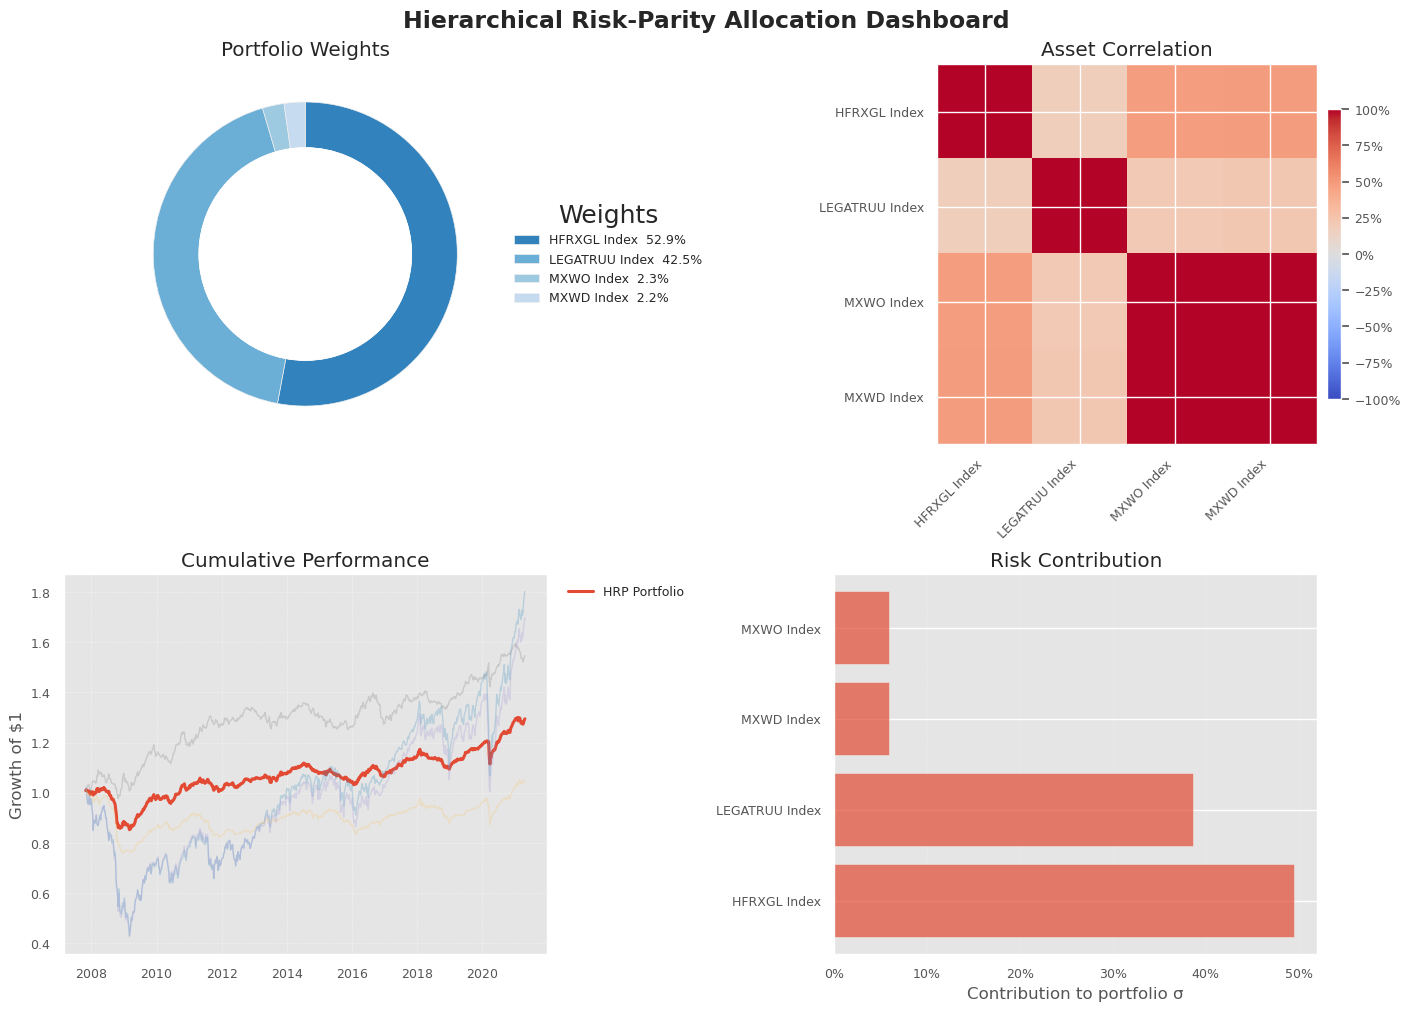

In [7]:
# --------------------------------------------------
# 1. Filter and clean allocation data
# --------------------------------------------------
df_allocation = data[['MXWO Index', 'MXWD Index', 'LEGATRUU Index', 'HFRXGL Index']]

# Check for invalid price values (NaNs or infs), print only if any are found
n_nans = df_allocation.isna().sum().sum()
n_infs = (~np.isfinite(df_allocation)).sum().sum()

if n_nans > 0 or n_infs > 0:
    print("⚠️ Invalid values found in df_allocation:")
    if n_nans > 0:
        print("NaNs per column:\n", df_allocation.isna().sum())
    if n_infs > 0:
        print("Infs per column:\n", (~np.isfinite(df_allocation)).sum())

# --------------------------------------------------
# 2. Compute returns, remove inf/nan
# --------------------------------------------------
df_returns = df_allocation.pct_change()
df_returns.replace([np.inf, -np.inf], np.nan, inplace=True)
df_returns.dropna(inplace=True)

if df_returns.empty:
    raise ValueError("All return rows are NaN or invalid after cleaning.")

FREQ = 52  # Weekly frequency

# --------------------------------------------------
# 3. Compute expected returns and covariance matrix
# --------------------------------------------------
mu = expected_returns.mean_historical_return(df_allocation, frequency=FREQ)
cov = risk_models.sample_cov(df_allocation, frequency=FREQ)

# --------------------------------------------------
# 4. Run HRP optimization
# --------------------------------------------------
hrp = HRPOpt(df_returns)
raw_wts = hrp.optimize()
wts = hrp.clean_weights()
weights_HRP = pd.Series(wts).sort_values(ascending=False)

print("\nHRP Weights (%):\n", (weights_HRP * 100).round(2))

# --------------------------------------------------
# 5. Compute risk contributions
# --------------------------------------------------
def risk_contribution(weights_vec, cov_matrix):
    port_var = np.dot(weights_vec, cov_matrix @ weights_vec)
    mrc = cov_matrix @ weights_vec
    rc = weights_vec * mrc / port_var
    return rc

cov_subset = cov.loc[weights_HRP.index, weights_HRP.index]
rc = risk_contribution(weights_HRP.values, cov_subset)
rc = pd.Series(rc, index=weights_HRP.index)

# --------------------------------------------------
# 6. Cumulative performance
# --------------------------------------------------
cum_rets_assets = (1 + df_returns).cumprod()
cum_rets_hrp = (cum_rets_assets * weights_HRP).sum(axis=1)

# ---------- global style tweaks --------------------------------
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "legend.fontsize":  9,
    "font.family":      "DejaVu Sans",
})
plt.style.use("ggplot")               # keep your base style

# ---------- helper mini-functions ------------------------------
def donut(ax, series, title):
    colors = plt.cm.tab20c(range(len(series)))
    wedges, _ = ax.pie(
        series.values,
        startangle=90,
        counterclock=False,
        colors=colors,
        wedgeprops=dict(width=0.30)   # donut!
    )
    ax.add_artist(plt.Circle((0, 0), 0.70, color="white"))
    ax.set_title(title)
    ax.legend(
        wedges,
        [f"{k}  {v:4.1%}" for k, v in series.items()],
        loc="center left", bbox_to_anchor=(1.02, 0.5),
        frameon=False, title="Weights"
    )

def corr_heatmap(ax, corr, title, fig):
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(corr)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr)))
    ax.set_yticklabels(corr.index)
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.ax.yaxis.set_major_formatter(PercentFormatter(1))

def cumulative(ax, cum_port, cum_assets, title):
    ax.plot(cum_port, label="HRP Portfolio", linewidth=2.2)
    for col in cum_assets.columns:
        ax.plot(cum_assets.index, cum_assets[col], alpha=0.25, linewidth=1)
    ax.set_ylabel("Growth of $1")
    ax.set_title(title)
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.00), frameon=False)

def rc_bar(ax, rc):
    rc = rc.sort_values(ascending=False)
    ax.barh(rc.index, rc.values, alpha=0.7)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xlabel("Contribution to portfolio σ")
    ax.set_title("Risk Contribution")
    ax.grid(axis="x", linestyle=":", linewidth=0.4, alpha=0.6)

# ---------- figure & mosaic layout -----------------------------
MOSAIC = """
AB
DE
"""
fig, axes = plt.subplot_mosaic(
    MOSAIC,
    figsize=(14, 10),
    layout="constrained"             # ← one layout engine → no clashes
)
fig.suptitle("Hierarchical Risk-Parity Allocation Dashboard",
             fontsize=17, fontweight="bold")

# ---------- populate each panel --------------------------------
donut(       axes["A"], weights_HRP,                         "Portfolio Weights")
corr_heatmap(axes["B"], df_returns[weights_HRP.index].corr(), "Asset Correlation", fig)
cumulative(  axes["D"], cum_rets_hrp, cum_rets_assets,   "Cumulative Performance")
rc_bar(      axes["E"], rc)

plt.show()


c:\Users\Ginevra\anaconda3\Lib\site-packages\pypfopt\plotting.py:41: UserWarning:

The figure layout has changed to tight



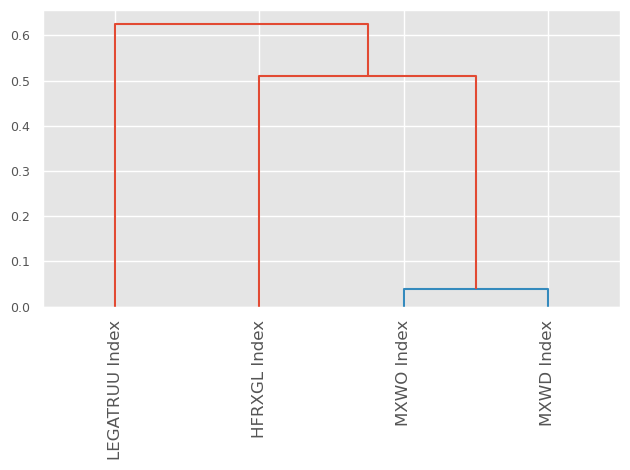

In [8]:
# 6-C HRP dendrogram (native pypfopt helper)
plotting.plot_dendrogram(hrp, show_tickers=True)
plt.show()


In [9]:
def price2ret(x):
    return x.pct_change()

def ret2price(x):
    return (1+x).cumprod()


## 4. Volatility Forecasting with GARCH

**Goal:** model short-term volatility dynamics with a rolling GARCH process.

**What happens here**
- Build annualized rolling volatility.
- Run train/validation/test GARCH search.
- Compare fitted and forecast volatility trajectories.


In [10]:
# ----------------------------------------------------------
# Build 1-month rolling volatility from weekly target returns
# ----------------------------------------------------------
# 1) Convert gross returns (1 + r_t) to simple returns r_t
# 2) Compute a 4-week rolling standard deviation
# 3) Annualize with sqrt(52)
# ----------------------------------------------------------
data['Target'] = price2ret(data[weights_HRP.index]).dot(weights_HRP)
data['Target']= ret2price(data['Target'])
returns = data.pct_change() + 1
returns.fillna(0, inplace=True)
weekly_target_ret=returns['Target']
weekly_ret = weekly_target_ret - 1                     # r_t in decimal
roll_vol   = weekly_ret.rolling(window=4).std()        # 4 weeks ≈ 1 month
roll_vol   = roll_vol * np.sqrt(52)                    # annualised
roll_vol.name = "1M_Rolling_Vol"
roll_vol=roll_vol['2011-04-13':]
fig = go.Figure()
fig.add_trace(go.Scatter(x=roll_vol.index, y=roll_vol,
                         mode="lines", name="Annualised σ (4-week window)"))
fig.update_layout(title="1-Month Rolling Volatility (Annualised)",
                  template="plotly_white",
                  yaxis_title="Volatility",
                  hovermode="x unified")
fig.show()


In [11]:
# ===================================================================
# Rolling volatility (roll_vol): GARCH grid search + out-of-sample forecast
# Note: append new observations with their true timestamps
# ===================================================================

# 1) Split data into train / validation / test segments
dates = roll_vol.index
T     = len(roll_vol)
cut_tr = int(0.6 * T)
cut_va = int(0.8 * T)

σ_tr = roll_vol.iloc[:cut_tr]
σ_va = roll_vol.iloc[cut_tr:cut_va]
σ_te = roll_vol.iloc[cut_va:]

# scale by 100 for arch
sc_tr = σ_tr * 100
sc_va = σ_va * 100

# 2) Grid search over p, q <= 3 using validation RMSE
cands, rmse_va = [(p,q) for p in range(1,4) for q in range(1,4)], {}

for p,q in cands:
    preds = []
    hist  = sc_tr.copy()

    for dt, σ_next in sc_va.items():                     # loop over timestamps
        mdl = arch_model(hist, p=p, q=q, mean="Zero", vol="Garch", rescale=False)
        res = mdl.fit(disp="off")
        f   = res.forecast(horizon=1, reindex=False)
        σ_hat = np.sqrt(f.variance["h.1"].iloc[-1])      # still x100
        preds.append(σ_hat/100)                          # back to scale 1
        # append new observation using its true timestamp
        hist = pd.concat([hist, pd.Series([σ_next], index=[dt])])

    rmse_va[(p,q)] = np.sqrt(mean_squared_error(σ_va, preds))

best_p, best_q = min(rmse_va, key=rmse_va.get)
print(f"The Best GARCH configuration is : ({best_p},{best_q})  \n- RMSE on Validation Set = {rmse_va[(best_p,best_q)]:.4f}")

# 3) Refit on train+validation, then forecast the test segment
σ_fit = roll_vol.iloc[:cut_va]
sc_fit= σ_fit*100

final = arch_model(sc_fit, p=best_p, q=best_q, mean="Zero", vol="Garch", rescale=False)
res   = final.fit(disp="off")

σ_fit_full = res.conditional_volatility/100
σ_fit_tr, σ_fit_va = σ_fit_full.iloc[:cut_tr], σ_fit_full.iloc[cut_tr:]

# forecasts on test
pred_test = []
hist = sc_fit.copy()

for dt, σ_obs in (σ_te*100).items():
    res_t = arch_model(hist, p=best_p, q=best_q, mean="Zero", vol="Garch", rescale=False).fit(disp="off")
    f     = res_t.forecast(horizon=1, reindex=False)
    σ_hat = np.sqrt(f.variance["h.1"].iloc[-1])/100
    pred_test.append(σ_hat)
    hist  = pd.concat([hist, pd.Series([σ_obs], index=[dt])])

σ_pred_te = pd.Series(pred_test, index=σ_te.index)

# 4) Plot fitted and forecast volatility paths
fig = go.Figure()
fig.add_trace(go.Scatter(x=dates,          y=roll_vol,      name="Realised σ", line=dict(color="black")))
fig.add_trace(go.Scatter(x=σ_fit_tr.index, y=σ_fit_tr,      name="Fitted (Train)", line=dict(color="royalblue")))
fig.add_trace(go.Scatter(x=σ_fit_va.index, y=σ_fit_va,      name="Fitted (Val)",   line=dict(color="darkorange")))
fig.add_trace(go.Scatter(x=σ_te.index,     y=σ_pred_te,     name="Forecast (Test)",line=dict(color="forestgreen")))
fig.add_vrect(x0=dates[cut_tr], x1=dates[cut_va],
              fillcolor="rgba(0,0,255,0.08)", line_width=0,
              annotation_text="Validation", annotation_position="top left")
fig.add_vrect(x0=dates[cut_va], x1=dates[-1],
              fillcolor="rgba(0,255,0,0.08)", line_width=0,
              annotation_text="Test", annotation_position="top left")
fig.update_layout(title=f"GARCH({best_p},{best_q}) Fit & Forecast",
                  template="plotly_white", yaxis_title="σ (Annualised)",
                  hovermode="x unified", height=520)
fig.show()


The Best GARCH configuration is : (1,2)  
• RMSE on Validation Set = 0.0088


## 5. Macro Regime Classification

**Goal:** classify macro environments and map them to investment regimes.

**What happens here**
- Download macro factors (GDP, CPI).
- Build the investment-clock state machine.
- Visualize regime transitions across time.


In [12]:
# Define the start and end date for the analysis
start_date = "2011-03-16"
end_date = "2022-01-1"

signals = pd.DataFrame(dict(GDP = web.DataReader("GDPC1", "fred", start_date, end_date)['GDPC1'],CPI = web.DataReader("CPILFESL", "fred", start_date, end_date)['CPILFESL'])).ffill().pct_change(12).dropna()
prices = yf.download(['IYC','IDU','IYZ','IYW','IYJ','IYH','IYF','IYE','IYK','IYM','IYR','IVV','GLD','TIP','EMB','LQD','SHY','TLT'],"2001-01-01",end = end_date)['Close']
#prices = prices.multiply(yf.download(['USDEUR=X'],'2010-01-04',end = end_date)['Close'],axis="index").dropna()

signals['GDP'] = signals['GDP'].shift(3)
signals['CPI'] = signals['CPI'].shift(1)
signals.dropna(inplace= True)


[*********************100%***********************]  18 of 18 completed


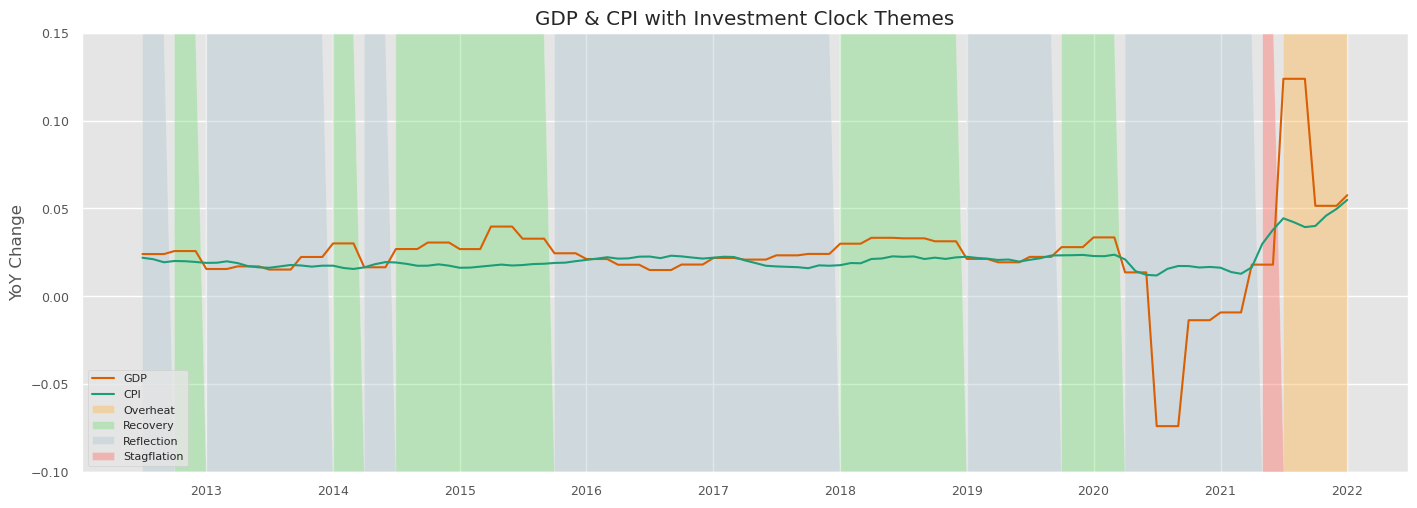

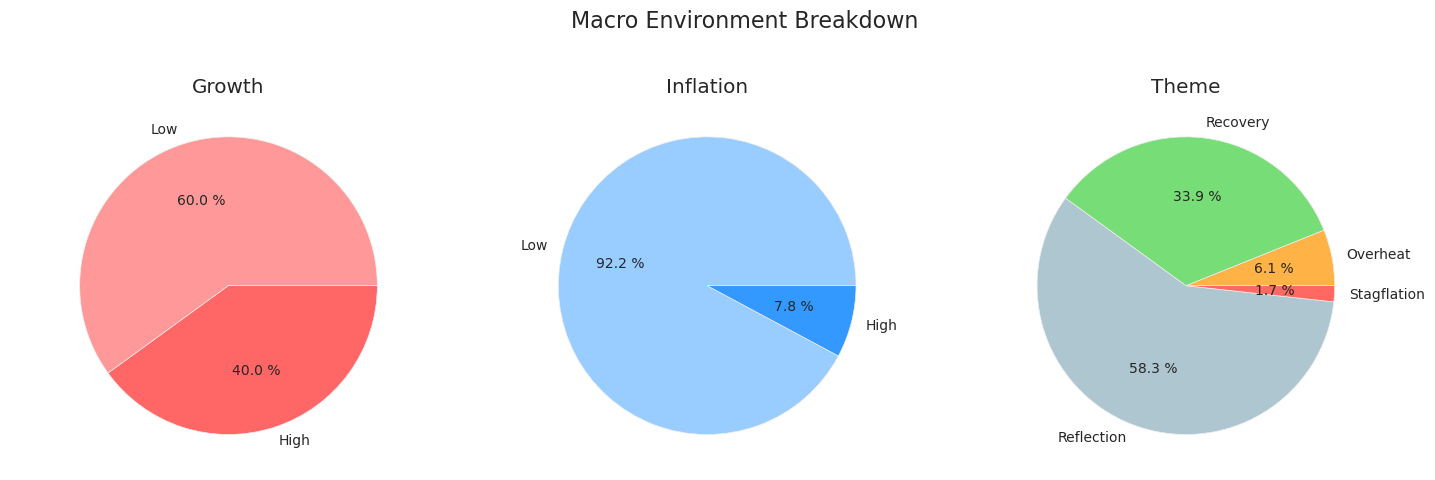

In [13]:
def InvestmentClockFixed(x, cuts={'GDP': 0.025, 'CPI': 0.03}):
    x_ = x.copy().assign(Growth=None, Inflation=None, Theme=None)

    x_.loc[x['GDP'] <= cuts['GDP'], 'Growth'] = 'Low'
    x_.loc[x['GDP'] > cuts['GDP'], 'Growth'] = 'High'
    x_.loc[x['CPI'] <= cuts['CPI'], 'Inflation'] = 'Low'
    x_.loc[x['CPI'] > cuts['CPI'], 'Inflation'] = 'High'

    x_.loc[(x_.Growth == 'Low') & (x_.Inflation == 'Low'), 'Theme'] = 'Reflection'
    x_.loc[(x_.Growth == 'High') & (x_.Inflation == 'Low'), 'Theme'] = 'Recovery'
    x_.loc[(x_.Growth == 'High') & (x_.Inflation == 'High'), 'Theme'] = 'Overheat'
    x_.loc[(x_.Growth == 'Low') & (x_.Inflation == 'High'), 'Theme'] = 'Stagflation'
    return x_.dropna()

# Apply the regime classification
themes = InvestmentClockFixed(signals, cuts={'GDP': 0.025, 'CPI': 0.025})

# Summer-inspired color palette
summer_colors = {
    'Overheat': '#FFB347',     # Orange
    'Recovery': '#77DD77',     # Mint green
    'Reflection': '#AEC6CF',   # Light blue
    'Stagflation': '#FF6961'   # Coral red
}

# Red palette for Growth
growth_colors = ['#FF9999', '#FF6666']           # Red shades

# Blue palette for Inflation
inflation_colors = ['#99CCFF', '#3399FF']        # Blue shades

# --- Time-series chart: GDP + CPI ---
fig, ax1 = plt.subplots(figsize=(17.1, 5.7))
y_lim = (-.1, .15)

ax1.plot(themes.index, themes['GDP'], label='GDP', color='#D95F02')
ax1.plot(themes.index, themes['CPI'], label='CPI', color='#1B9E77')

for theme, color in summer_colors.items():
    ax1.fill_between(
        themes.index, y_lim[0], y_lim[1],
        where=(themes.Theme == theme),
        interpolate=True,
        facecolor=color,
        alpha=0.4,
        label=theme if theme not in ax1.get_legend_handles_labels()[1] else ""
    )

ax1.set_title("GDP & CPI with Investment Clock Themes")
ax1.set_ylabel("YoY Change")
ax1.set_ylim(y_lim)
ax1.legend(loc="lower left", fontsize=8)
ax1.grid(True)

# --- Consistent pie charts ---
fig, (ax2, ax3, ax4) = plt.subplots(1, 3, figsize=(15, 5))

# Growth pie chart
growth_counts = themes.Growth.value_counts()
ax2.pie(
    growth_counts,
    autopct='%.1f %%',
    labels=growth_counts.index,
    colors=growth_colors,
    textprops={'fontsize': 10}
)
ax2.set_title('Growth')
ax2.axis('equal')

# Inflation pie chart
inflation_counts = themes.Inflation.value_counts()
ax3.pie(
    inflation_counts,
    autopct='%.1f %%',
    labels=inflation_counts.index,
    colors=inflation_colors,
    textprops={'fontsize': 10}
)
ax3.set_title('Inflation')
ax3.axis('equal')

# Theme pie chart
theme_counts = themes.Theme.value_counts().sort_index()
ax4.pie(
    theme_counts,
    autopct='%.1f %%',
    labels=theme_counts.index,
    colors=[summer_colors[k] for k in theme_counts.index],
    textprops={'fontsize': 10}
)
ax4.set_title('Theme')
ax4.axis('equal')

plt.suptitle("Macro Environment Breakdown", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


<details>
<summary><strong>Replica using Elastic Net & Adding Transaction Cost</strong></summary>

In this section, we address the problem of replicating a financial index by using **Elastic Net regression**, an approach that combines both L1 (Lasso) and L2 (Ridge) regularization. This method is particularly useful when dealing with **high-dimensional financial datasets**, where multicollinearity and overfitting are concerns.

### Why Elastic Net?

- **L1 (Lasso)** helps with feature selection by shrinking less important weights to zero.
- **L2 (Ridge)** stabilizes the model when predictors are highly correlated.
- Elastic Net balances both effects via a mixing parameter `α`, providing **sparse yet stable** portfolio weights.

##  ElasticNetBacktester – Overview

This class implements a comprehensive **backtesting engine** for portfolio replication using **Elastic Net regression** on financial time series. It is designed to:

- Model asset returns using a **rolling window** approach.
- Support different return formats: **log returns**, **simple returns**, or **prices**.
- Automatically scale the prediction target and input features using `MinMaxScaler`.
- Perform **hyperparameter tuning** through `GridSearchCV` over a configurable Elastic Net parameter grid (`alpha`, `l1_ratio`).
- Apply **time-aware cross-validation** using `TimeSeriesSplit` to prevent data leakage in time series data.
- In practical applications, it is critical to account for **transaction costs**, which can significantly erode the performance of a replicated portfolio. These costs are introduced into the optimization as a penalty on **weight turnover**, i.e., the change in allocation from one period to the next.

### Risk-Aware Weight Scaling

We propose a dynamic adjustment of portfolio weights based on an estimated Value-at-Risk (VaR). The VaR is computed using a t-skewed distribution fitted via maximum likelihood optimization (scipy.optimize.minimize). This enables a more prudent rescaling of portfolio exposure in high-risk regimes.

If the historical VaR (based on 1% confidence and 4-week horizon) **exceeds a fixed threshold** (`max_var_threshold`), the weights are **prudently scaled down** to ensure more conservative exposure during volatile regimes.

</details>

## 6. Elastic Net Portfolio Replication

**Goal:** train a rolling Elastic Net replicator with transaction-cost awareness.

**What happens here**
- Define the backtesting engine and risk controls.
- Prepare multiple feature/target representations.
- Compare tracking quality across input types.


### 6.0 Backtester Engine Definition

Core class definition for rolling Elastic Net replication, including:
- hyperparameter search,
- VaR-aware scaling,
- transaction-cost penalty,
- diagnostics and plots.


In [14]:
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
except ImportError:
    go = None
    make_subplots = None
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="deep")

# ---------- Global risk and cost parameters ----------
var_confidence = 0.01
var_horizon = 4
max_var_threshold = 0.08
transaction_cost_rate = 0.0005


@dataclass
class ElasticNetBacktester:
    X: pd.DataFrame
    y: pd.Series
    window: int = 150
    feature_window: int = 12
    param_grid: Mapping[str, Sequence[Any]] | None = None
    cv: int = 5
    trading_cost: float = 0.0005  # example default

    # Specifies whether y is 'log_return' or 'simple_return' or 'prices'
    input_type: str = "log_return"  # or "simple_return"

    # Results
    y_pred: np.ndarray | None = None
    y_true: np.ndarray | None = None
    coefs: np.ndarray | None = None
    gross_exp: np.ndarray | None = None
    var_values: np.ndarray | None = None
    scaling_factors: np.ndarray | None = None

    # Metrics
    mse: float | None = None
    te: float | None = None
    te_vol: float | None = None
    info_ratio: float | None = None
    ann_turnover: float | None = None
    ann_trading_cost: float | None = None

    def __post_init__(self) -> None:
        if self.param_grid is None:
            self.param_grid = {
                "alpha": [0.001, 0.01, 0.1, 1],
                "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
            }
        if self.input_type not in {"log_return", "simple_return", "prices"}:
            raise ValueError(f"Invalid input_type: {self.input_type}. Use 'log_return' or 'simple_return' or 'prices'.")
    # ------------------------------------------------------------------
    # VALUE-AT-RISK
    # ------------------------------------------------------------------
    def calculate_var(self, returns, confidence=var_confidence, horizon=var_horizon):
        returns = np.asarray(returns)
        returns = returns[~np.isnan(returns)]
        if len(returns) < 10:
            return np.nan

        def tskew_negloglik(params):
            nu, loc, scale = params
            if nu <= 2 or scale <= 0:
                return np.inf
            return -np.sum(t.logpdf(returns, df=nu, loc=loc, scale=scale))

        init_params = [6, np.mean(returns), np.std(returns)]
        bounds = [(2.1, 30), (None, None), (1e-6, None)]
        result = minimize(tskew_negloglik, init_params, bounds=bounds)

        if not result.success:
            return np.nan

        nu, loc, scale = result.x
        return -t.ppf(confidence, df=nu, loc=loc, scale=scale) * np.sqrt(horizon)

    # ------------------------------------------------------------------
    # MAIN BACK-TEST LOOP
    # ------------------------------------------------------------------
    def run_backtest(self) -> None:
        n_samples = len(self.X)
        self._preds = []
        self._truth = []
        self._coefs = []
        self._gross = []
        var_values = []
        scaling_factors = []
        replica_returns = []
        prev_weights = None

        for i in range(self.window, n_samples):
            X_train = self.X.iloc[i - self.window: i]
            y_train = self.y.iloc[i - self.window: i]
            X_val = self.X.iloc[i: i + 1]
            y_val = self.y.iloc[i]

            scaler_X = MinMaxScaler()
            X_train_scaled = scaler_X.fit_transform(X_train)
            X_val_scaled = scaler_X.transform(X_val)

            scaler_y = MinMaxScaler()
            y_train_scaled = scaler_y.fit_transform(
                y_train.values.reshape(-1, 1)
            ).flatten()

            gs = GridSearchCV(
                ElasticNet(fit_intercept=False, max_iter=10000),
                self.param_grid,
                cv=TimeSeriesSplit(n_splits=self.cv),
                scoring="neg_mean_squared_error",
                n_jobs=-1,
            )
            gs.fit(X_train_scaled, y_train_scaled)

            pred_scaled = gs.predict(X_val_scaled)[0]
            pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
            self._preds.append(pred)
            self._truth.append(y_val)

            beta_scaled = gs.best_estimator_.coef_
            beta_unscaled = beta_scaled / scaler_X.scale_

            scaling_factor = 1.0
            if len(replica_returns) >= 12:
                hist_returns = np.array(replica_returns[-52:])
                var = self.calculate_var(hist_returns)
                if var > max_var_threshold:
                    scaling_factor = max_var_threshold / var
                    var = self.calculate_var(hist_returns * scaling_factor)
            else:
                var = np.nan

            if np.abs(beta_unscaled).sum() > 0:
                weights = beta_unscaled / np.sum(beta_unscaled)
            else:
                weights = np.zeros_like(beta_unscaled)
            weights *= scaling_factor

            return_replica = np.dot(X_val.values, weights.T).item()

            if prev_weights is not None:
                turnover = np.sum(np.abs(weights - prev_weights))
                cost = self.trading_cost * turnover
                return_replica -= cost
            prev_weights = weights.copy()

            replica_returns.append(return_replica)
            self._coefs.append(weights)
            self._gross.append(np.abs(weights).sum())
            var_values.append(var)
            scaling_factors.append(scaling_factor)

        self.y_pred = np.asarray(self._preds)
        self.y_true = np.asarray(self._truth)
        self.coefs = np.vstack(self._coefs)
        self.gross_exp = np.asarray(self._gross)
        self.var_values = np.asarray(var_values)
        self.scaling_factors = np.asarray(scaling_factors)

        dates = self._idx()
        if self.input_type == "log_return":
            self.prices_replica = pd.Series(np.exp(np.cumsum(self.y_pred)), index=dates)
            self.prices_target = pd.Series(np.exp(np.cumsum(self.y_true)), index=dates)
        elif self.input_type == "simple_return":
            self.prices_replica = pd.Series(np.cumprod(self.y_pred), index=dates)
            self.prices_target = pd.Series(np.cumprod(self.y_true), index=dates)
        elif self.input_type == "prices":
            self.prices_replica = pd.Series(self.y_pred, index=dates)
            self.prices_target = pd.Series(self.y_true, index=dates)
        else:
            raise ValueError(f"Unknown input_type: {self.input_type}")

    # ------------------------------------------------------------------
    # ACCESSOR
    # ------------------------------------------------------------------
    def get_prediction_dataframe(self) -> pd.DataFrame:
        """
        Return time-aligned price series based on predictions and actual values.

        If the input was:
        - 'log_return': convert to price via exp(cumsum)
        - 'simple_return': convert to price via cumprod
        - 'prices': use as is

        Columns
        -------
        Actual     = Reconstructed price series from self.y_true
        Predicted  = Reconstructed price series from self.y_pred
        """
        if self.y_pred is None or self.y_true is None:
            raise RuntimeError("call run_backtest() first")

        dates = self._idx()

        if self.input_type == "log_return":
            actual = np.exp(np.cumsum(self.y_true))
            predicted = np.exp(np.cumsum(self.y_pred))
        elif self.input_type == "simple_return":
            actual = np.cumprod(1 + self.y_true)
            predicted = np.cumprod(1 + self.y_pred)
        elif self.input_type == "prices":
            actual = self.y_true
            predicted = self.y_pred
        else:
            raise ValueError(f"Unknown input_type: {self.input_type}")

        return pd.DataFrame({"Actual": actual, "Predicted": predicted}, index=dates)

    # ------------------------------------------------------------------
    # METRICS
    # ------------------------------------------------------------------
    def compute_metrics(self) -> None:
        if self.y_pred is None or self.y_true is None:
            raise RuntimeError("call run_backtest() first")

        self.mse = mean_squared_error(self.y_true, self.y_pred)

        # --- Convert to simple net returns ---
        if self.input_type == "log_return":
            r_true = np.expm1(self.y_true)
            r_pred = np.expm1(self.y_pred)
        elif self.input_type == "simple_return":
            r_true = self.y_true 
            r_pred = self.y_pred 
        elif self.input_type == "prices":
            r_true = self.y_true[1:] / self.y_true[:-1] - 1
            r_pred = self.y_pred[1:] / self.y_pred[:-1] - 1
        else:
            raise ValueError(f"Unknown input_type: {self.input_type}")

        # --- Align returns if needed (drop first element for prices) ---
        if self.input_type == "prices":
            te = r_true - r_pred
        else:
            te = r_true - r_pred  # already aligned

        self.te = te
        self.te_vol = te.std() * np.sqrt(52)
        self.info_ratio = te.mean() / self.te_vol if self.te_vol > 0 else np.nan

        # --- Annualised turnover and trading cost ---
        dw = np.diff(self.coefs, axis=0)
        self.ann_turnover = (np.abs(dw).sum(axis=1) / 2).mean() * 52
        self.ann_trading_cost = self.ann_turnover * self.trading_cost

    # ------------------------------------------------------------------
    # INTERNAL DATE INDEX
    # ------------------------------------------------------------------
    def _idx(self) -> pd.DatetimeIndex:
        return self.X.index[self.window: self.window + len(self.y_pred)]

    # ------------------------------------------------------------------
    # PLOTTING UTILITIES
    # ------------------------------------------------------------------
    def plot_prediction(self, interactive: bool = True):
        dates = self._idx()
        if interactive and go is not None:
            fig = go.Figure()
            fig.add_trace(go.Scatter(x=dates, y=self.y_true, name="Actual", mode="lines"))
            fig.add_trace(go.Scatter(x=dates, y=self.y_pred, name="Predicted", mode="lines"))
            fig.update_layout(title="Elastic-Net: Prediction vs Actual",
                              template="plotly_white",
                              xaxis_title="Date",
                              yaxis_title=self.y.name,
                              hovermode="x unified")
            fig.show()
            return fig
        sns.lineplot(x=dates, y=self.y_true, label="Actual", linewidth=2)
        sns.lineplot(x=dates, y=self.y_pred, label="Predicted", linewidth=2)
        plt.title("Elastic-Net: Prediction vs Actual")
        _style_xticks()
        plt.show()

    def plot_tracking_error(self, interactive: bool = True):
        te = self.te
        if interactive and go is not None:
            colors = np.where(te >= 0, "#2ca02c", "#d62728")
            fig = go.Figure(go.Bar(x=dates, y=te, marker_color=colors, name="Tracking Error"))
            fig.add_hline(y=0, line_dash="dash", line_color="gray")
            fig.update_layout(title="Tracking Error",
                              template="plotly_white",
                              xaxis_title="Date",
                              yaxis_title="Error",
                              hovermode="x")
            fig.show()
            return fig
        sns.barplot(x=dates, y=te, palette=["g" if v >= 0 else "r" for v in te])
        plt.axhline(0, linestyle=":", color="gray")
        plt.title("Tracking Error")
        _style_xticks()
        plt.show()

    def plot_gross_exposure(self, shift: float = 1.0, interactive: bool = True):
        dates = self._idx()
        series = self.gross_exp + shift
        if interactive and go is not None:
            fig = go.Figure(go.Scatter(x=dates, y=series, mode="lines", name="Gross Exp"))
            fig.update_layout(title=f"Gross Exposure (shift + {shift})",
                              template="plotly_white",
                              xaxis_title="Date",
                              yaxis_title="Exposure",
                              hovermode="x unified")
            fig.show()
            return fig
        sns.lineplot(x=dates, y=series)
        plt.title("Gross Exposure")
        _style_xticks()
        plt.show()

    def plot_var_series(self, interactive: bool = True):
        dates = self._idx()
        if interactive and go is not None:
            fig = go.Figure()
            fig.add_trace(go.Scatter(x=dates, y=self.var_values, mode="lines", name="VaR"))
            fig.add_hline(y=max_var_threshold, line_dash="dash", line_color="red")
            fig.update_layout(title="Estimated VaR Over Time",
                              template="plotly_white",
                              xaxis_title="Date",
                              yaxis_title="VaR",
                              hovermode="x unified")
            fig.show()
            return fig
        plt.plot(dates, self.var_values, label="VaR")
        plt.axhline(max_var_threshold, linestyle="--", color="red", label="Max VaR")
        plt.title("Estimated VaR Over Time")
        _style_xticks()
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_scaling_factors(self, interactive: bool = True):
        dates = self._idx()
        if interactive and go is not None:
            fig = go.Figure()
            fig.add_trace(go.Scatter(x=dates, y=self.scaling_factors, mode="lines", name="Scaling Factor"))
            fig.update_layout(title="Weight Scaling Factors",
                              template="plotly_white",
                              xaxis_title="Date",
                              yaxis_title="Scaling Factor",
                              hovermode="x unified")
            fig.show()
            return fig
        plt.plot(dates, self.scaling_factors, label="Scaling Factor")
        plt.title("Scaling Factors Over Time")
        _style_xticks()
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_weights(self, asset_names: list[str], interactive: bool = True):
        dates = self._idx()

        if len(dates) != len(self.coefs):
            raise ValueError("Mismatch between number of dates and weights.")

        if interactive and _USE_PLOTLY:
            fig = go.Figure()
            for i, name in enumerate(asset_names):
                fig.add_trace(go.Scatter(x=dates, y=self.coefs[:, i], name=name, mode="lines"))
            fig.update_layout(
                title="Asset Weights Over Time",
                template="plotly_white",
                xaxis_title="Date",
                yaxis_title="Weight",
                hovermode="x unified"
            )
            fig.show()
            return  # prevent running the Matplotlib fallback path.

        # fallback static plot
        plt.figure(figsize=(12, 6))
        for i, name in enumerate(asset_names):
            plt.plot(dates, self.coefs[:, i], label=name, linewidth=1.5)
        plt.title("Asset Weights Over Time", fontsize=14)
        plt.xlabel("Date", fontsize=12)
        plt.ylabel("Weight", fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=10)
        _style_xticks()
        plt.tight_layout()
        plt.show()

    def plot_portfolio_prices(self):
        df = self.get_prediction_dataframe()
        if go is not None:
            fig = go.Figure()
            fig.add_trace(go.Scatter(x=df.index, y=df["Actual"], name="Actual", mode="lines"))
            fig.add_trace(go.Scatter(x=df.index, y=df["Predicted"], name="Predicted", mode="lines"))
            fig.update_layout(title="Cumulative Portfolio Value",
                            template="plotly_white",
                            xaxis_title="Date",
                            yaxis_title="Value",
                            hovermode="x unified")
            fig.show()
        else:
            df.plot(title="Cumulative Portfolio Value", figsize=(10, 5))
            _style_xticks()
            plt.grid(True)
            plt.show()

    # ------------------------------------------------------------------
    # TEXT SUMMARY
    # ------------------------------------------------------------------
    def summary(self) -> None:
        if self.mse is None:
            raise RuntimeError("compute_metrics() first")
        print("\nElastic-Net performance summary")
        print("─" * 35)
        print(f"MSE:                   {self.mse: .4e}")
        print(f"Tracking Error Vol:    {self.te_vol: .4f}")
        print(f"Information Ratio:     {self.info_ratio: .4f}")
        print(f"Annual Turnover:       {self.ann_turnover: .4f}")
        print(f"Annual Trading Costs:  {self.ann_trading_cost: .4f}")


# ------------------------------------------------------------------
# matplotlib fallback tick formatter
# ------------------------------------------------------------------
if go is None:
    def _style_xticks() -> None:
        plt.xlabel("Date")
        plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        plt.xticks(rotation=45)
else:
    def _style_xticks():
        pass


### 6.0.1 Feature Engineering Utilities

Build aligned `X`/`y` datasets for three representations:
- log returns,
- simple returns,
- price levels.


In [15]:
def prepare_features_and_target_for_elastic_net(
    data: pd.DataFrame,
    weights: Mapping[str, float] | None = None,
    cols_to_drop: list[str] | None = None,
) -> dict:
    """
    Prepares weekly log-return features and target series for elastic net backtester.

    Starting from daily price data, the function:
    - Computes a weighted target portfolio based on given asset weights,
    - Calculates gross returns (1 + r_t),
    - Converts them to log returns via log(1 + r_t),
    - Filters out invalid or misaligned rows,
    - Returns NumPy arrays of log returns ready for modeling.

    Parameters
    ----------
    data : pd.DataFrame
        Time-indexed DataFrame with daily asset prices.
    weights : pd.Series
        Asset weights (index = asset names, values = weights) used to compute the portfolio target.

    Returns
    -------
    dict
        Dictionary with keys 'log_return', 'simple_return', and 'prices',
        each mapping to a tuple (X, y).
    """

     # -------- local helper functions --------
    pct = lambda x: x.pct_change()
    cum = lambda x: (1 + x).cumprod()

    # ---- default settings ----

    if weights is None:
        weights = {
            "HFRXGL Index": 0.5156,
            "MXWO Index": 0.0264,
            "LEGATRUU Index": 0.4316,
            "MXWD Index": 0.0263,
        }

    if cols_to_drop is None:
        cols_to_drop = ["Target", "VG1 Comdty", "NQ1 Comdty"]

    
    if isinstance(weights, pd.Series):
        common_cols = list(weights.index)
    else:
        common_cols = list(weights)

    target_ret = pct(data[common_cols]).mul(pd.Series(weights), axis=1).sum(axis=1)
    target = cum(target_ret).dropna()

    # ------------ X -----------------
    drop_cols = common_cols + cols_to_drop
    X = data.drop(columns=[c for c in drop_cols if c in data.columns])
    X = cum(pct(X)).dropna()

    # -------- align indices --------
    idx = target.index.intersection(X.index)
    # -------- First backtest -----

    target, X =  target.loc[idx], X.loc[idx]

    # -------- Second backtest -----

    # 1. Compute returns of assets in the target
    target_returns = price2ret(data[weights.index]).dot(weights)

    # 2. Reconstruct target price series from returns
    target_price = pd.Series((1 + target_returns).cumprod(), index=target_returns.index)

    # 3. Add target price to the original data
    data = data.copy()  # avoid modifying original
    data['Target'] = target_price

    # 4. Compute simple returns for all assets and target
    returns = data.pct_change()
    returns.fillna(0, inplace=True)

    # 5. Columns to exclude: assets in weights + others
    excluded = list(weights.index) + ['Target', 'VG1 Comdty', 'NQ1 Comdty']
    features = returns.columns.drop(excluded, errors='ignore')

    # 6. Extract features and target
    X_week = returns[features]
    y_week = returns['Target']
    
    # -------- Third backtest -----

    log_returns_assets = np.log(data[weights.index] / data[weights.index].shift(1)).dropna()

    log_returns_target = log_returns_assets.dot(weights)

    target_price = pd.Series(np.exp(log_returns_target.cumsum()), index=log_returns_target.index)

    data = data.copy()
    data['Target'] = target_price

    log_returns = np.log(data / data.shift(1))
    log_returns.replace([np.inf, -np.inf], np.nan, inplace=True)
    log_returns.dropna(inplace=True)


    excluded = list(weights.index) + ['Target', 'VG1 Comdty', 'NQ1 Comdty']
    features = log_returns.columns.drop(excluded, errors='ignore')

    X_log = log_returns[features]
    target_log = log_returns['Target']
    
    # Return all variants
    return {
        "log_return": (X_log, target_log),
        "simple_return": (X_week, y_week),
        "prices": (X, target),
    }


### 6.1 Single Elastic Net Run
Run one full backtest instance to validate the pipeline end-to-end.


In [16]:
# Single-run sanity check of the Elastic Net pipeline (log-return representation)
backtest_inputs = prepare_features_and_target_for_elastic_net(data, weights_HRP)
X_in = backtest_inputs['log_return'][0]
y_in = backtest_inputs['log_return'][1]
bt = ElasticNetBacktester(
        X=X_in,
        y=y_in,
        window=150,
        input_type='log_return',
    )
bt.run_backtest()
bt.plot_portfolio_prices()


### 6.2 Multi-Input Comparison
Compare replication quality across log-return, simple-return, and price-based model inputs.


Running backtest for input type: log_return
Running backtest for input type: simple_return
Running backtest for input type: prices


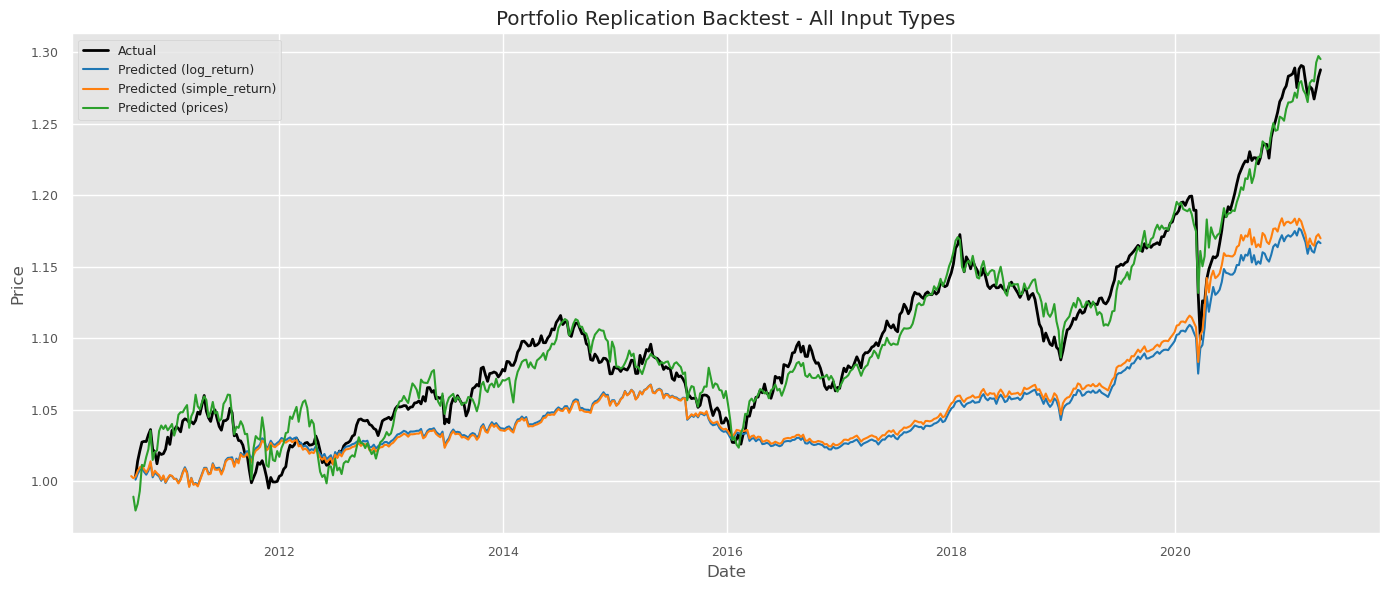

In [17]:
# Dictionary: input_type -> aligned (X, y) pairs
backtest_inputs = prepare_features_and_target_for_elastic_net(data, weights_HRP)

results = {}
actual_prices = None  # store once

for input_type, (X_in, y_in) in backtest_inputs.items():
    print(f"Running backtest for input type: {input_type}")
    bt = ElasticNetBacktester(
        X=X_in,
        y=y_in,
        window=150,
        input_type=input_type,
    )
    bt.run_backtest()
    bt.compute_metrics()
    df = bt.get_prediction_dataframe()
    results[input_type] = df["Predicted"]
    if actual_prices is None:
        actual_prices = df["Actual"]

# --- Single comparison plot ---
plt.figure(figsize=(14, 6))
plt.plot(actual_prices.index, actual_prices.values, color="black", label="Actual", linewidth=2)

colors = {
    "log_return": "tab:blue",
    "simple_return": "tab:orange",
    "prices": "tab:green"
}

for input_type, pred_series in results.items():
    plt.plot(pred_series.index, pred_series.values, label=f"Predicted ({input_type})", color=colors[input_type])

plt.title("Portfolio Replication Backtest - All Input Types")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Observations from Backtest Across Input Types

Surprisingly, we observe that the model trained directly on **prices** (green line) appears to track the actual portfolio (black line) more closely than the return-based models.

This finding is counterintuitive, as returns are typically used to model portfolio dynamics due to their stationarity and additive properties. However, in this specific setup, the price-based model provides better empirical results in terms of tracking performance.

---

Given this result, we choose to **model the prices directly** with this Elastic Net framework, and focus the next part of the analysis on the **replicating portfolio derived from price regression**. We will evaluate stability, turnover, and out-of-sample tracking error of this strategy in more detail.

### 6.3 Elastic Net Diagnostic Plots
Inspect prediction quality, tracking error, exposure, VaR scaling, and weight dynamics.


In [18]:
# Execute full Elastic Net diagnostics on the selected backtest instance
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    _USE_PLOTLY = True
except ImportError:
    _USE_PLOTLY = False
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="deep")
X = backtest_inputs['prices'][0]
bt.compute_metrics()
bt.summary()
asset_names = X.columns.to_list()
bt.plot_prediction()
bt.plot_tracking_error()
bt.plot_gross_exposure()
bt.plot_var_series()
bt.plot_scaling_factors()
bt.plot_weights(asset_names, interactive=True)
df_elastic = bt.get_prediction_dataframe()



Elastic-Net performance summary
───────────────────────────────────
MSE:                    1.7385e-04
Tracking Error Vol:     0.0411
Information Ratio:     -0.0005
Annual Turnover:        2.7404
Annual Trading Costs:   0.0014


### 6.4 Performance and Risk Metrics
Compute return/risk summaries and probabilistic Sharpe diagnostics for the replicated portfolio.


In [19]:
# ---------- metric helpers ----------
def _resample_yearly(series: pd.Series) -> pd.Series:
    return series.resample("Y").last()

def calc_metrics(series: pd.Series, rf: float = 0) -> dict[str, float]:
    yr_price   = _resample_yearly(series)
    yr_ret     = yr_price.pct_change().dropna()

    yrs        = (yr_price.index[-1] - yr_price.index[0]).days / 365.25
    cagr       = (yr_price.iloc[-1] / yr_price.iloc[0])**(1/yrs) - 1
    vol        = yr_ret.std()

    # intrayear max-drawdown
    ret        = series.pct_change().dropna()
    cum        = (1 + ret).cumprod()
    mdd        = ((cum - cum.cummax()) / cum.cummax()).min()

    sharpe     = (yr_ret.mean() - rf) / vol           if vol      else np.nan

    return dict(
        CAGR                = cagr,
        Yearly_Volatility   = vol,
        Max_Drawdown        = mdd,
        Sharpe              = sharpe
    )

# ---------- compute ----------
bench_metrics = calc_metrics(df_elastic["Actual"]*100)
etf_metrics   = calc_metrics(df_elastic["Predicted"]*100)

order   = ["CAGR","Yearly_Volatility",
           "Max_Drawdown","Sharpe"]

bench_v = [bench_metrics[m] for m in order]
etf_v   = [etf_metrics[m]   for m in order]

# ---------- Plotly dashboard ----------
fig = make_subplots(rows=2, cols=3, subplot_titles=order,
                    horizontal_spacing=0.08, vertical_spacing=0.15)

idx = 0
for r in range(1,3):
    for c in range(1,4):
        if idx >= len(order): break
        fig.add_trace(
            go.Bar(x=["Benchmark","Tx-adj."],
                   y=[bench_v[idx], etf_v[idx]],
                   marker_color=["#1f77b4","#ff7f0e"]),
            row=r, col=c
        )
        idx += 1

fig.update_layout(
    title="Performance metrics: Benchmark vs Tx-cost adjusted portfolio",
    template="plotly_white",
    showlegend=False,
    height=600,
)
fig.show()


In [20]:
# ===============================================================
# Probabilistic Sharpe Ratio (López-de Prado) for weekly data
# ===============================================================

# ---------------------------------------------------------------
# 0.  PREP – weekly returns from your existing DataFrame
# ---------------------------------------------------------------
# prices_df must have two columns:
#    • "Actual"  -> benchmark weekly prices
#    • "Adj"     -> Tx-cost-adjusted portfolio weekly prices

ret_bm = df_elastic["Actual"].pct_change().dropna()
ret_pf = df_elastic["Predicted"].pct_change().dropna()

# align indices (inner join)
ret_pf, ret_bm = ret_pf.align(ret_bm, join="inner")

# ---------------------------------------------------------------
# 1.  Core formulas
# ---------------------------------------------------------------
def estimated_sharpe_ratio(r: pd.Series) -> float:
    """Weekly Sharpe ratio (risk-free = 0)."""
    return r.mean() / r.std(ddof=1)

def estimated_sr_stdev(r: pd.Series) -> float:
    """Std-error of SR estimate (see López-de Prado, 2012)."""
    n      = len(r)
    sr     = estimated_sharpe_ratio(r)
    skew   = st.skew(r, bias=False)
    kurt   = st.kurtosis(r, fisher=False, bias=False)
    return np.sqrt((1 + 0.5*sr**2 - skew*sr + 0.25*(kurt-3)*sr**2) / (n-1))

def probabilistic_sharpe_ratio(r: pd.Series, sr_star: float = 0.0) -> float:
    """
    PSR = Prob{ SR_hat > SR* }  where SR* = sr_star.
    """
    sr_hat  = estimated_sharpe_ratio(r)
    sr_std  = estimated_sr_stdev(r)
    z_value = (sr_hat - sr_star) / sr_std
    return st.norm.cdf(z_value)

# ---------------------------------------------------------------
# 2.  Compute stats
# ---------------------------------------------------------------
sr_bm   = estimated_sharpe_ratio(ret_bm)
sr_pf   = estimated_sharpe_ratio(ret_pf)

psr_vs_zero = probabilistic_sharpe_ratio(ret_pf, sr_star=0.0)
psr_vs_bm   = probabilistic_sharpe_ratio(ret_pf, sr_star=sr_bm)

ann_sr_pf = sr_pf * np.sqrt(52)
ann_sr_bm = sr_bm * np.sqrt(52)

# ---------------------------------------------------------------
# 3.  Results
# ---------------------------------------------------------------
print(f"Weekly Sharpe  (portfolio) : {sr_pf:.3f}")
print(f"Weekly Sharpe  (benchmark) : {sr_bm:.3f}")
print(f"Annualised SR (portfolio)  : {ann_sr_pf:.3f}")
print(f"Annualised SR (benchmark)  : {ann_sr_bm:.3f}\n")

print(f"Prob. SR > 0              : {psr_vs_zero:.2%}")
print(f"Prob. SR > benchmark SR   : {psr_vs_bm:.2%}")


Weekly Sharpe  (portfolio) : 0.084
Weekly Sharpe  (benchmark) : 0.096
Annualised SR (portfolio)  : 0.607
Annualised SR (benchmark)  : 0.690

Prob. SR > 0              : 97.28%
Prob. SR > benchmark SR   : 39.65%


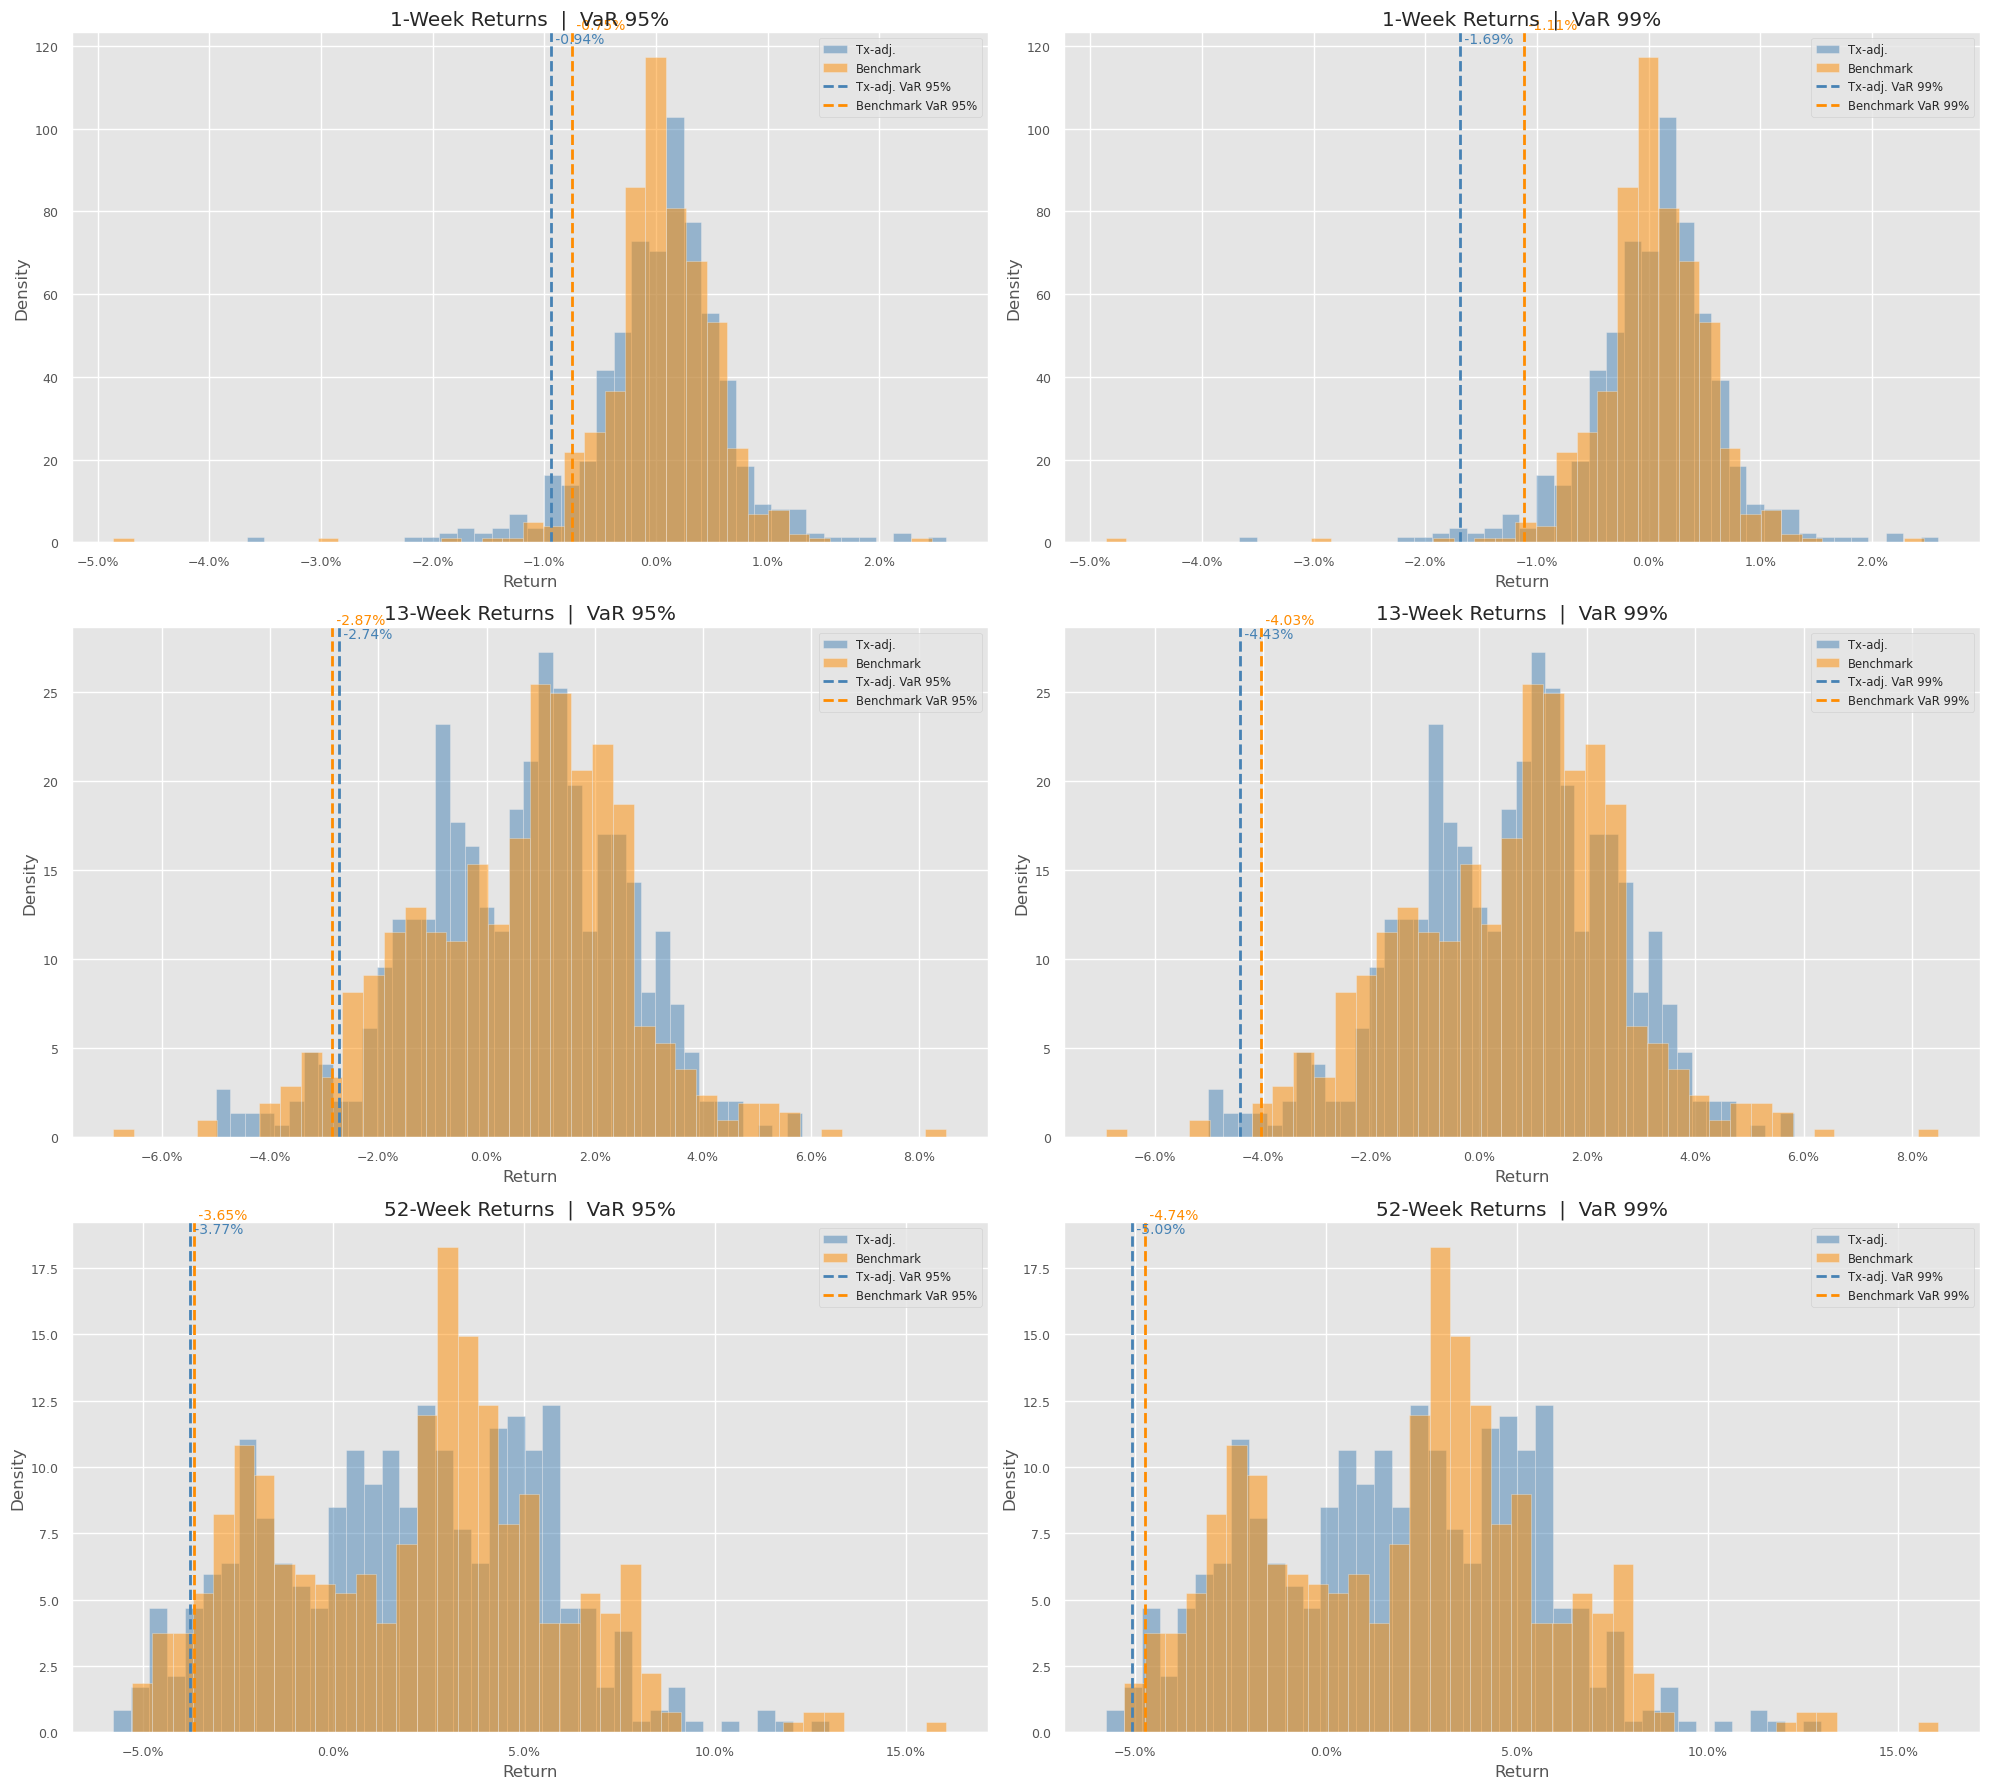

In [21]:
# -------------------------------------------------------------------
#  helper funcs (unchanged)
# -------------------------------------------------------------------
def _calculate_var(ret, cl):
    return np.percentile(ret, 100 - cl)

def _calc_interval_returns(series, intervals):
    return {p: series.pct_change(p).dropna() for p in intervals}

# -------------------------------------------------------------------
def plot_var_analysis(prices_df,
                      intervals=(1, 13, 52),
                      confidence_levels=(95, 99),
                      portfolio_label="Tx-adj.",
                      benchmark_label="Benchmark"):

    pf_ret = _calc_interval_returns(prices_df["Predicted"],    intervals)
    bm_ret = _calc_interval_returns(prices_df["Actual"], intervals)

    var_vals = {
        p: {cl: {
                "Portfolio": _calculate_var(pf_ret[p], cl),
                "Benchmark": _calculate_var(bm_ret[p], cl)
             } for cl in confidence_levels}
        for p in intervals
    }

    # -------- dynamic grid size ------------------------------------
    n_plots = len(intervals) * len(confidence_levels)
    n_cols  = 2                                # keep two per row
    n_rows  = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10*n_cols, 6*n_rows))
    axes = axes.flatten()

    pf_color, bm_color = "steelblue", "#FF8C00"

    for i, p in enumerate(intervals):
        for j, cl in enumerate(confidence_levels):
            k  = i * len(confidence_levels) + j        # flat index
            ax = axes[k]

            # histogram overlay
            ax.hist(pf_ret[p], bins=40, density=True, alpha=0.5,
                    color=pf_color, label=portfolio_label)
            ax.hist(bm_ret[p], bins=40, density=True, alpha=0.5,
                    color=bm_color, label=benchmark_label)

            v_pf = var_vals[p][cl]["Portfolio"]
            v_bm = var_vals[p][cl]["Benchmark"]
            ax.axvline(v_pf, color=pf_color, ls="--", lw=2,
                       label=f"{portfolio_label} VaR {cl}%")
            ax.axvline(v_bm, color=bm_color, ls="--", lw=2,
                       label=f"{benchmark_label} VaR {cl}%")
            ax.text(v_pf, ax.get_ylim()[1], f" {v_pf:.2%}",
                    color=pf_color, va="top", ha="left")
            ax.text(v_bm, ax.get_ylim()[1], f" {v_bm:.2%}",
                    color=bm_color, va="bottom", ha="left")

            ax.set_title(f"{p}-Week Returns  |  VaR {cl}%")
            ax.set_xlabel("Return"); ax.set_ylabel("Density")
            ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
            ax.grid(True); ax.legend(fontsize="small")

    # remove any unused axes (when n_plots is odd)
    for ax in axes[n_plots:]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()


plot_var_analysis(df_elastic,
                  intervals=(1, 13, 52),
                  confidence_levels=(95, 99))   # both 95 % and 99 %


In [22]:
# ------------------------------------------------------------
# 1)  helper: rolling percentage change on weekly data
# ------------------------------------------------------------
def rolling_return(series: pd.Series, window_weeks: int) -> pd.Series:
    """
    Rolling total return over *window_weeks* weeks.

    Example
    -------
    window_weeks = 26  ->  six-month rolling return
    window_weeks = 52  ->  one-year  rolling return
    """
    return series.div(series.shift(window_weeks)).sub(1).dropna()

# ------------------------------------------------------------
# 2)  set up data
# ------------------------------------------------------------
# weekly cumulative-growth series produced by your back-tester
pf_price = df_elastic["Predicted"]   # portfolio / replica
bm_price = df_elastic["Actual"]      # benchmark

# horizons expressed in weeks
horizons = [("6-Month", 26), ("1-Year", 52)]

pf_roll = {lbl: rolling_return(pf_price, w) for lbl, w in horizons}
bm_roll = {lbl: rolling_return(bm_price, w) for lbl, w in horizons}

# common weekly index so every subplot lines up perfectly
common_index = pf_roll[horizons[0][0]].index
for lbl, _ in horizons:
    common_index = common_index.intersection(pf_roll[lbl].index) \
                               .intersection(bm_roll[lbl].index)
for lbl in pf_roll:
    pf_roll[lbl] = pf_roll[lbl].reindex(common_index)
    bm_roll[lbl] = bm_roll[lbl].reindex(common_index)

# ------------------------------------------------------------
# 3)  Plotly dashboard
# ------------------------------------------------------------
colors = dict(Portfolio="#d62728",
              Benchmark="#1f77b4",
              Zero="#888888")

fig = make_subplots(
    rows=len(horizons), cols=1,
    shared_xaxes=True,
    vertical_spacing=0.07,
    subplot_titles=[f"<b>{lbl}</b> Rolling Returns" for lbl, _ in horizons],
)

for i, (lbl, _) in enumerate(horizons, start=1):
    # Predicted / portfolio series
    fig.add_trace(
        go.Scatter(
            x=common_index,
            y=pf_roll[lbl],
            mode="lines",
            name="Predicted",
            legendgroup="pred",
            showlegend=(i == 1),
            line=dict(color=colors["Portfolio"], width=2),
            hovertemplate="%{x|%Y-%m-%d}<br>Predicted: %{y:.2%}<extra></extra>",
        ),
        row=i, col=1
    )
    # Actual / benchmark series
    fig.add_trace(
        go.Scatter(
            x=common_index,
            y=bm_roll[lbl],
            mode="lines",
            name="Actual",
            legendgroup="bench",
            showlegend=(i == 1),
            line=dict(color=colors["Benchmark"], width=2),
            hovertemplate="%{x|%Y-%m-%d}<br>Actual: %{y:.2%}<extra></extra>",
        ),
        row=i, col=1
    )
    # zero reference line
    fig.add_trace(
        go.Scatter(
            x=common_index,
            y=[0] * len(common_index),
            mode="lines",
            line=dict(color=colors["Zero"], width=1, dash="dot"),
            showlegend=False,
        ),
        row=i, col=1
    )

fig.update_layout(
    height=460 * len(horizons),
    title=dict(
        text="<b>Rolling Returns</b>: Predicted vs Actual",
        x=0.5, xanchor="center",
    ),
    template="plotly_white",
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom", y=1.15,
        xanchor="right",  x=1,
        title=None,
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="lightgray",
        borderwidth=1,
    ),
    margin=dict(t=100, b=50),
)
fig.update_yaxes(tickformat=".1%", title="Return")
fig.update_xaxes(title="Date")

fig.show()


### 6.5 Factor Exposure Validation
Evaluate benchmark vs. replicated portfolio sensitivity using Fama-French style factor regressions.


In [23]:
# Suppress the FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning, message="The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.")
factors = reader.DataReader("Developed_5_Factors", "famafrench")[0]
factors = factors.loc[:'2021-03']
factors=factors[['Mkt-RF','SMB','HML','RMW','CMA']]


In [24]:
# ------------------------------------------------------------
# 1. Factor data: keep only factor columns
# ------------------------------------------------------------
factor_cols = ["SMB", "HML", "RMW", "CMA"]
preferred_start, preferred_end = "2020-05", "2021-03"
ff_source_start = "1990-07"  # avoid pandas-datareader default rolling-window behavior

def _prepare_factors(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Robust index parsing: PeriodIndex, datetime, or YYYYMM integer/string
    if isinstance(out.index, pd.PeriodIndex):
        idx_dt = out.index.to_timestamp(how="end")
    else:
        raw_idx = pd.Index(out.index)
        if pd.api.types.is_integer_dtype(raw_idx):
            idx_dt = pd.to_datetime(raw_idx.astype(str), format="%Y%m", errors="coerce")
        else:
            idx_str = raw_idx.astype(str).str.strip()
            parsed_ym = pd.to_datetime(idx_str, format="%Y%m", errors="coerce")
            parsed_generic = pd.to_datetime(idx_str, errors="coerce")
            idx_dt = parsed_ym.where(parsed_ym.notna(), parsed_generic)

    out.index = pd.to_datetime(idx_dt, errors="coerce")
    out = out.loc[out.index.notna()].sort_index()
    out.index = out.index.to_period("M")

    missing_cols = [c for c in factor_cols if c not in out.columns]
    if missing_cols:
        raise KeyError(f"Missing FF factor columns: {missing_cols}. Available: {list(out.columns)}")

    out = (
        out[factor_cols]
        .apply(pd.to_numeric, errors="coerce")
        .groupby(level=0)
        .last()
        .dropna()
    )
    return out

factors_all = _prepare_factors(factors)

if factors_all.empty:
    raw_ff = reader.DataReader(
        "Developed_5_Factors", "famafrench",
        start=ff_source_start, end=preferred_end
    )[0]
    factors_all = _prepare_factors(raw_ff)

# ------------------------------------------------------------
# 2. Monthly returns from price series
# ------------------------------------------------------------
def monthly_return(s: pd.Series) -> pd.Series:
    monthly_prices = s.resample("M").last()
    returns = monthly_prices.pct_change().dropna()
    returns.index = returns.index.to_period("M")
    return returns

bm_ret = monthly_return(df_elastic["Actual"])
pf_ret = monthly_return(df_elastic["Predicted"])


def _idx_span(idx: pd.Index) -> str:
    return f"{idx.min()} -> {idx.max()}" if len(idx) else "empty"


def _common_idx(factor_df: pd.DataFrame) -> pd.Index:
    return bm_ret.index.intersection(pf_ret.index).intersection(factor_df.index)


# Try the preferred analysis window first.
factors4 = factors_all.loc[preferred_start:preferred_end]
common_idx = _common_idx(factors4)

# If no overlap exists in that window, gracefully fallback to all available overlap.
if common_idx.empty:
    print(
        "No overlap found in the preferred FF4 window "
        f"({preferred_start} -> {preferred_end}). Falling back to full available overlap."
    )
    factors4 = factors_all
    common_idx = _common_idx(factors4)

if common_idx.empty:
    raise ValueError(
        "No overlapping monthly observations between returns and factors. "
        f"Benchmark span: {_idx_span(bm_ret.index)} | "
        f"Portfolio span: {_idx_span(pf_ret.index)} | "
        f"Factors span: {_idx_span(factors_all.index)}"
    )

bm_r = bm_ret.loc[common_idx]
pf_r = pf_ret.loc[common_idx]
X = factors4.loc[common_idx]

# ------------------------------------------------------------
# 3. Fama-French 4-Factor regression (OLS)
# ------------------------------------------------------------
def ff4_reg(ret: pd.Series, factors_df: pd.DataFrame, label: str) -> pd.Series:
    frame = pd.concat([ret.rename("ret"), factors_df], axis=1).dropna()
    min_obs = len(factors_df.columns) + 2  # quick sanity threshold for stable OLS

    if frame.shape[0] < min_obs:
        raise ValueError(
            f"Not enough observations for {label} regression. "
            f"Need at least {min_obs}, got {frame.shape[0]}."
        )

    X_reg = sm.add_constant(frame[factors_df.columns], has_constant="add")
    model = sm.OLS(frame["ret"], X_reg, missing="drop").fit()
    betas = model.params.drop("const")
    betas.name = label
    return betas

bm_beta = ff4_reg(bm_r, X, "Benchmark")
pf_beta = ff4_reg(pf_r, X, "Tx-adj. ETF").reindex(bm_beta.index)

# ------------------------------------------------------------
# 4. Side-by-side bar plot: estimated betas
# ------------------------------------------------------------
labels = bm_beta.index.tolist()
x = list(range(len(labels)))
w = 0.35  # bar width

fig = go.Figure()
fig.add_bar(
    x=x,
    y=bm_beta.values,
    width=w,
    name="Benchmark",
    marker_color="#1f77b4",  # blue
)

fig.add_bar(
    x=[i + w for i in x],
    y=pf_beta.values,
    width=w,
    name="Tx-adj. ETF",
    marker_color="#d62728",  # red
)

window_label = f"{common_idx.min()} -> {common_idx.max()}"

fig.update_layout(
    title=f"4-Factor Betas (SMB, HML, RMW, CMA)  |  {window_label}",
    xaxis=dict(tickvals=[i + w / 2 for i in x], ticktext=labels),
    yaxis_title="Factor Loading (beta)",
    template="plotly_white",
    bargap=0.15,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    height=500,
)
fig.show()


## KalmanPortfolio: Dynamic Portfolio Tracking with Transaction Cost Adjustment

The `KalmanPortfolio` class implements a **rolling Kalman Filter** to replicate a target portfolio using **log-returns** of a set of financial assets. It dynamically estimates portfolio weights to track a target log-return series, and accounts for **transaction costs** during rebalancing.

---

### Model Setup

The Kalman filter is applied to a linear state-space model over asset **log-returns**:

#### State Equation (weight dynamics)

$$
\boldsymbol{\beta}_t = \mathbf{A} \boldsymbol{\beta}_{t-1} + \mathbf{B} \mathbf{u}_t, \quad \mathbf{u}_t \sim \mathcal{N}(0, \mathbf{Q})
$$

- $\boldsymbol{\beta}_t$ = latent portfolio weights at time $t$  
- $\mathbf{A}$ = identity matrix (assumes random walk on weights)  
- $\mathbf{B}$ = diagonal matrix (from asset variances)  
- $\mathbf{Q}$ = state noise covariance matrix (empirical)

#### Observation Equation (return replication)

$$
y_t = \mathbf{x}_t^\top \boldsymbol{\beta}_t + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, R)
$$

- $y_t$ = target log-return at time $t$  
- $\mathbf{x}_t$ = log-returns of the assets  
- $R$ = observation noise variance (estimated from data)

---

### Core Functionality

- `fit_predict(prices)`  
  Re-estimates portfolio weights every `window_size` steps using a Kalman filter, then performs a one-step-ahead forecast.

- `adjust_for_costs()`  
  Converts predicted log-returns to price levels and applies **transaction cost penalties** based on turnover.

- `get_price_dataframe()`  
  Returns a DataFrame with actual, predicted, and adjusted price paths.

## 7. Kalman Filter Dynamic Replication

**Goal:** estimate time-varying portfolio exposures with a rolling Kalman filter.

**What happens here**
- Prepare weekly features and target returns.
- Fit the dynamic state-space replicator.
- Build transaction-cost-adjusted price paths.


### 7.1 Kalman Inputs Preparation

Create target and exogenous feature matrices used by the rolling Kalman model.


In [25]:
# Ensure deterministic behavior for reproducible Kalman experiments
np.random.seed(0)
def prepare_features_and_target_for_kalman(data: pd.DataFrame, weights: pd.Series):
    """
    Prepares weekly and monthly feature/target matrices for modeling.

    Parameters
    ----------
    data : pd.DataFrame
        Time-indexed DataFrame with daily price data for all assets.
    weights : pd.Series
        Asset weights with index as asset names (e.g. 'MXWO Index') and values as weights.

    Returns
    -------
    X_week : np.ndarray
        Weekly feature matrix.
    y_week : np.ndarray
        Weekly target values.
    X_month : np.ndarray
        Monthly feature matrix.
    y_month : np.ndarray
        Monthly target values.
    features : list
        Names of selected weekly features.
    features_monthly : list
        Names of selected monthly features.
    """

    # Compute weighted target for both frequencies
    data['Target'] = price2ret(data[weights.index]).dot(weights)
    data['Target']= ret2price(data['Target'])

    # Gross returns
    returns = data.pct_change() + 1
    returns.fillna(0, inplace=True)

    # Columns to exclude: assets in weights + others
    excluded = list(weights.index) + ['Target', 'VG1 Comdty', 'NQ1 Comdty', 'DU1 Comdty', 'TY1 Comdty']

    features = returns.columns.drop(excluded, errors='ignore')

    # Extract feature matrices and targets
    X_week = returns[features].values
    y_week = returns['Target'].values

    return X_week, y_week, list(features), returns

X_week_k, y_week_k,  features_k,  returns_k,  = prepare_features_and_target_for_kalman(data, weights_HRP)


In [26]:
class KalmanPortfolio:
    """
    Kalman-filter rolling portfolio with transaction-cost adjustment.

    Parameters
    ----------
    X_week : ndarray   (#obs × #features) weekly explanatory returns
    y_week : ndarray   (#obs,)           target weekly return series
    returns : ndarray  (#obs,)           same target series
    dates_index : pd.DatetimeIndex       aligned to rows of X_week
    window_size : int                    rolling window length (weeks)
    cost_per_unit : float                proportional trading-cost rate
    """

    # ------------------------------------------------------------------
    # CONSTRUCTOR
    # ------------------------------------------------------------------
    def __init__(
        self,
        X_week,
        y_week,
        returns,
        dates_index,
        window_size: int = 104,
        cost_per_unit: float = 0.0005,
    ):
        # keep original simple-return matrices for reference
        self.original_y_week = y_week
        self.original_X_week = X_week

        # convert to log returns for the Kalman filter
        self.X_week = self._simple_to_log_returns(X_week)
        self.y_week = self._simple_to_log_returns(y_week)

        self.returns = returns
        self.dates = dates_index
        self.window_size = window_size
        self.cost_per_unit = cost_per_unit

        # placeholders populated during fit / adjustment
        self.y_test_kf, self.y_pred_kf = [], []
        self.dates_kf, self.portfolio_weights = [], []
        self.adjusted_portfolio_prices = []

        # Kalman initial parameters
        self.num_features = X_week.shape[1]
        self.A = np.eye(self.num_features)
        self.B = np.diag(np.diag(np.cov(X_week.T)))
        self.Q = np.cov(X_week, rowvar=False)
        self.R = np.std(y_week) ** 2  # observation variance

        # will be set when `fit_predict()` is called
        self.prices = None

    # ------------------------------------------------------------------
    # STATIC HELPERS
    # ------------------------------------------------------------------
    @staticmethod
    def calculate_transaction_costs(change_in_positions, cost_per_trade):
        return np.abs(change_in_positions).sum() * cost_per_trade

    @staticmethod
    def ret2price(ret):
        price = np.ones(len(ret))
        for i in range(1, len(ret)):
            price[i] = price[i - 1] * ret[i]
        return price

    @staticmethod
    def _log_to_simple_returns(log_returns):
        return np.expm1(log_returns)

    @staticmethod
    def _simple_to_log_returns(simple_returns):
        return np.log1p(simple_returns)

    # ------------------------------------------------------------------
    # CORE METHODS
    # ------------------------------------------------------------------
    def fit_predict(self, prices=None):
        """
        Rolling-window Kalman filter.

        Notes
        -----
        • Re-estimates the state every ``window_size`` weeks.
        • Collects one-step-ahead predictions and normalised weights.
        • *Must* be called before ``adjust_for_costs`` or plotting.

        Parameters
        ----------
        prices : pd.DataFrame or ndarray
            Same shape as ``X_week``; used to convert return weights to
            capital-weighted positions.
        """
        if prices is None:
            raise ValueError("You must provide the price matrix to normalise weights.")

        self.prices = prices

        for i in range(self.window_size, len(self.returns) - 1):
            X_train = self.X_week[i - self.window_size : i]
            y_train = self.y_week[i - self.window_size : i]
            X_test  = self.X_week[i : i + 1]

            x_hat = np.zeros(self.num_features)
            P_hat = np.eye(self.num_features)

            # ———  Kalman recursion over the rolling window  ——— #
            for t in range(self.window_size):
                x_hat = self.A @ x_hat + self.B @ np.random.randn(self.num_features)
                P_hat = self.A @ P_hat @ self.A.T + self.Q

                C      = X_train[t].reshape(1, -1)
                K      = P_hat @ C.T @ np.linalg.inv(C @ P_hat @ C.T + self.R)
                resid  = y_train[t] - C @ x_hat
                x_hat  = x_hat + (K @ resid).flatten()
                P_hat  = (np.eye(self.num_features) - K @ C) @ P_hat

            # ———  one-step-ahead forecast  ——— #
            C_test = X_test
            x_pred = self.A @ x_hat + self.B @ np.random.randn(self.num_features)
            P_pred = self.A @ P_hat @ self.A.T + self.Q
            K_test = P_pred @ C_test.T @ np.linalg.inv(C_test @ P_pred @ C_test.T + self.R)
            resid  = y_train[-1] - (C_test @ x_pred)
            x_pred = x_pred + (K_test @ resid).flatten()

            # normalise weights by asset price at date i
            price_vector  = self.prices.iloc[i]
            raw_weights   = x_pred * price_vector
            norm_weights  = (
                raw_weights / np.sum(raw_weights) if np.sum(raw_weights) != 0
                else np.zeros_like(raw_weights)
            )

            self.portfolio_weights.append(norm_weights)
            self.y_test_kf.append(self.y_week[i])
            self.y_pred_kf.append((C_test @ x_pred)[0])
            self.dates_kf.append(self.dates[i])

        return self

    def adjust_for_costs(self):
        """
        Convert predicted log-returns to cumulative prices and apply a
        turnover-based transaction-cost drag.
        """
        self.adjusted_portfolio_prices = [1]  # start at 1

        simple_y_pred_kf = self._log_to_simple_returns(np.array(self.y_pred_kf))
        w  = np.array(self.portfolio_weights)
        dw = np.abs(np.diff(w, axis=0))          # |Δw| for turnover

        for i, delta in enumerate(dw):
            tc = self.calculate_transaction_costs(delta, self.cost_per_unit)
            next_price = self.adjusted_portfolio_prices[-1] * simple_y_pred_kf[i + 1] - tc
            self.adjusted_portfolio_prices.append(next_price)

        prices_test_kf       = self._log_to_simple_returns(self.y_test_kf)
        self.prices_test_kf  = self.ret2price(np.array(prices_test_kf))
        self.prices_pred_kf  = self.ret2price(np.array(simple_y_pred_kf))

        return self

    # ------------------------------------------------------------------
    #  NEW: CONVENIENCE ACCESSOR
    # ------------------------------------------------------------------
    def get_price_dataframe(self) -> pd.DataFrame:
        """
        Return a DataFrame with *Actual* and *Tx-cost-adj.* price paths.

        Call sequence
        -------------
        >>> kalman = KalmanPortfolio(...).fit_predict(prices).adjust_for_costs()
        >>> df = kalman.get_price_dataframe()

        Returns
        -------
        pd.DataFrame
            index   : ``self.dates_kf`` (weekly)
            columns : 'Actual', 'Tx-cost adj.'
        """
        if not hasattr(self, "prices_test_kf") or not hasattr(self, "adjusted_portfolio_prices"):
            raise RuntimeError("Run fit_predict() and adjust_for_costs() before calling get_price_dataframe().")

        return pd.DataFrame(
            {
                "Actual":        self.prices_test_kf,
                "Tx-cost adj.":  self.adjusted_portfolio_prices,
            },
            index=pd.DatetimeIndex(self.dates_kf, name="Date"),
        )

    # ------------------------------------------------------------------
    #  PLOTTING
    # ------------------------------------------------------------------
    def plot(self):
        if not hasattr(self, "prices_test_kf"):
            raise RuntimeError("Run adjust_for_costs() before plot().")

        dates = self.dates_kf

        # log-returns for tracking-error bar-plot
        r_b = np.diff(np.log(self.prices_test_kf))
        r_p = np.diff(np.log(self.prices_pred_kf))
        te_returns = r_p - r_b
        colors = np.where(te_returns >= 0, "#2ca02c", "#d62728")

        fig = make_subplots(
            rows=2, cols=1, shared_xaxes=True,
            row_heights=[0.7, 0.3], vertical_spacing=0.05,
        )

        # price paths
        fig.add_trace(go.Scatter(x=dates, y=self.prices_test_kf,
                                 name="Actual", mode="lines"), row=1, col=1)
        fig.add_trace(go.Scatter(x=dates, y=self.prices_pred_kf,
                                 name="Predicted", mode="lines"), row=1, col=1)
        fig.add_trace(go.Scatter(x=dates, y=self.adjusted_portfolio_prices,
                                 name="Tx-cost adj.", mode="lines"), row=1, col=1)

        # tracking-error bars (aligned with r_* diff, hence dates[1:])
        fig.add_trace(
            go.Bar(x=dates[1:], y=te_returns,
                   marker_color=colors, name="Tracking error"),
            row=2, col=1,
        )
        fig.add_hline(y=0, row=2, col=1, line_dash="dash", line_color="gray")

        loss = self.prices_pred_kf[-1] - self.adjusted_portfolio_prices[-1]
        tracking_error_std = np.std(te_returns)
        stats = (f"Tx-return loss: {loss:.3f}   |   "
                 f"Tracking Error (vol): {tracking_error_std:.3f}")

        fig.update_layout(
            title="Kalman-filter portfolio (weekly)",
            template="plotly_white",
            hovermode="x unified",
            height=700,
            legend=dict(orientation="h", yanchor="bottom", y=1.02,
                        xanchor="right", x=1),
            annotations=[dict(
                xref="paper", yref="paper", x=0, y=-0.23, showarrow=False,
                text=stats, font=dict(size=12)
            )],
        )
        fig.show()
        return self


### 7.2 Model Fitting and Cost Adjustment

Fit the Kalman replicator and generate adjusted trajectories including trading costs.


In [27]:
# Instantiate and execute the rolling Kalman replication workflow
model = KalmanPortfolio(
    X_week      = X_week_k,
    y_week      = y_week_k,
    returns     = y_week_k,        # same vector; kept for legacy reasons
    dates_index = data.index,
    window_size = 104,           # 2-year rolling window
    cost_per_unit = 0.0005       # trading-cost assumption
)
drop_cols = ['MXWO Index', 'MXWD Index', 'LEGATRUU Index', 'HFRXGL Index', "Target", "VG1 Comdty", "NQ1 Comdty", 'DU1 Comdty', 'TY1 Comdty']
df = data.drop(columns=[c for c in drop_cols if c in data.columns])
df = df.iloc[1:]
(model
 .fit_predict(prices=df)        # run rolling Kalman filter
 .adjust_for_costs()   # build cumulative price paths incl. Tx-costs
 .plot())              # interactive Plotly dashboard


### 7.3 Output Series Extraction

Extract model output series for downstream scenario analysis.


In [28]:
# Scale modeled price paths to an easier-to-read nominal level
df_kalman = model.get_price_dataframe()*1000


In [29]:
# Baseline notional used for timing simulations
initial_amount=10000


In [30]:
# Split predicted and benchmark series for downstream scenario tests
df_kalman_pred=df_kalman['Tx-cost adj.']
df_kalman_actual=df_kalman['Actual']


## 8. DCA vs Lump-Sum Timing Analysis

**Goal:** compare entry-timing impact between one-shot and staged investing.

**What happens here**
- Run the simulator on replicated prices.
- Repeat the same analysis on benchmark prices.
- Compare best/worst entry windows and distribution of outcomes.


In [31]:
class DCAvsLumpSumSimulator:
    """
    Comparison: Lump-Sum vs. Dollar-Cost Averaging.

    Parameters
    ----------
    price_series : pd.Series | pd.DataFrame
        Price series (DatetimeIndex). If a DataFrame is provided,
        the first column is used.
    initial_amount : float
        Total capital to invest.
    investment_periods : int, default 12
        Number of DCA tranches.
    freq_days : int, default 25
        Calendar days between tranches.
    """

    # ───────────────────────────────────────────────────────────────
    # INIT
    # ───────────────────────────────────────────────────────────────
    def __init__(
        self,
        price_series: "pd.Series | pd.DataFrame",
        initial_amount: float,
        investment_periods: int = 12,
        freq_days: int = 25,
    ):
        self.price = price_series.squeeze().sort_index()
        self.initial = float(initial_amount)
        self.investment_periods = int(investment_periods)
        self.freq_days = int(freq_days)

        self._run_backtest()

    # ───────────────────────────────────────────────────────────────
    # CORE CALCULATIONS
    # ───────────────────────────────────────────────────────────────
    def _calc_lump_sum(self) -> pd.Series:
        latest_price = self.price.iloc[-1]
        num_shares = self.initial / self.price
        return (latest_price * num_shares).rename("LumpSum")

    def _dca_value_from(self, start_date) -> float:
        inv_amount = self.initial / self.investment_periods

        all_dates = pd.date_range(
            start_date, periods=self.investment_periods, freq=f"{self.freq_days}D"
        )
        valid_dates = all_dates[all_dates < self.price.index[-1]]
        closest_idx = self.price.index.searchsorted(valid_dates)
        stock_prices = self.price.iloc[closest_idx]

        total_shares = (inv_amount / stock_prices).sum()
        uninvested_cash = inv_amount * (all_dates >= self.price.index[-1]).sum()

        return uninvested_cash + self.price.iloc[-1] * total_shares

    def _calc_dca(self) -> pd.Series:
        values = [self._dca_value_from(dt) for dt in self.price.index]
        return pd.Series(values, index=self.price.index, name="DCA")

    def _run_backtest(self):
        self.lumpsum = self._calc_lump_sum()
        self.dca = self._calc_dca()
        self.diff = self.dca - self.lumpsum

        self.vol_lump = self.lumpsum.pct_change().std() * 100
        self.vol_dca = self.dca.pct_change().std() * 100

        wins = (self.dca > self.lumpsum).sum()
        losses = (self.dca < self.lumpsum).sum()
        self.win_pct_dca = wins / len(self.price) * 100
        self.win_pct_lump = losses / len(self.price) * 100

    # ───────────────────────────────────────────────────────────────
    # TEXT REPORT
    # ───────────────────────────────────────────────────────────────
    def summary(self):
        print(
            f"DCA outperforms Lump-Sum in {self.win_pct_dca:.1f}% of weeks; "
            f"Lump-Sum outperforms DCA in {self.win_pct_lump:.1f}%."
        )
        print(
            f"Weekly volatility  |  Lump-Sum: {self.vol_lump:.2f}%   "
            f"DCA: {self.vol_dca:.2f}%"
        )

    def best_worst_report(self):
        """Print best/worst entry dates for Lump-Sum and DCA, preserving the original logic."""
        # Lump-Sum
        print("\nLump Sum Investment")
        print(
            "The best day to invest a $",
            str(int(self.initial)),
            "lump sum was on",
            self.lumpsum.idxmax().strftime("%b %d %Y"),
            "and would be worth $",
            str(round(self.lumpsum.max(), 2)),
            "on",
            self.lumpsum.index[-1].strftime("%b %d %Y"),
        )
        print(
            "The worst day to invest a $",
            str(int(self.initial)),
            "lump sum was on",
            self.lumpsum.idxmin().strftime("%b %d %Y"),
            "and would be worth $",
            str(round(self.lumpsum.min(), 2)),
            "on",
            self.lumpsum.index[-1].strftime("%b %d %Y"),
        )

        # DCA
        print("\nDollar Cost Averaging Investment")
        print(
            "The best day to start DCA a $",
            str(int(self.initial)),
            "investment was on",
            self.dca.idxmax().strftime("%b %d %Y"),
            "and would be worth $",
            str(round(self.dca.max(), 2)),
            "on",
            self.dca.index[-1].strftime("%b %d %Y"),
        )
        print(
            "The worst day to start DCA a $",
            str(int(self.initial)),
            "investment was on",
            self.dca.idxmin().strftime("%b %d %Y"),
            "and would be worth $",
            str(round(self.dca.min(), 2)),
            "on",
            self.dca.index[-1].strftime("%b %d %Y"),
        )

    # ───────────────────────────────────────────────────────────────
    # PLOTLY CHARTS
    # ───────────────────────────────────────────────────────────────
    def plot_lump_sum(self, template="plotly_white"):
        px.line(
            self.lumpsum,
            title=f"Lump-Sum – ${self.initial:,.0f}",
            labels={"value": "Value (USD)", "index": "Date"},
            template=template,
        ).update_traces(line=dict(width=2, color="#2ca02c")).show()

    def plot_dca(self, template="plotly_white"):
        px.line(
            self.dca,
            title=f"DCA ({self.investment_periods} tranche)",
            labels={"value": "Value (USD)", "index": "Date"},
            template=template,
        ).update_traces(line=dict(width=2, color="#1f77b4")).show()

    def plot_comparison(self, template="plotly_white"):
        fig = go.Figure()
        fig.add_trace(
            go.Scatter(
                x=self.lumpsum.index,
                y=self.lumpsum,
                mode="lines",
                name="Lump-Sum",
                line=dict(width=2, color="#2ca02c"),
            )
        )
        fig.add_trace(
            go.Scatter(
                x=self.dca.index,
                y=self.dca,
                mode="lines",
                name="DCA",
                line=dict(width=2, color="#1f77b4"),
            )
        )
        fig.update_layout(
            title=f"Comparison of the porfolio's value: Lump Sum vs. DCA – ${self.initial:,.0f}",
            yaxis_title="Value (USD)",
            template=template,
            legend=dict(x=0.02, y=0.98, borderwidth=1),
        )
        fig.show()

    def plot_difference(self, template="plotly_white"):
        pos = self.diff.where(self.diff > 0)
        neg = self.diff.where(self.diff < 0)

        fig = go.Figure()

        # red area (DCA > LS)
        fig.add_trace(
            go.Scatter(
                x=pos.index,
                y=pos,
                mode="lines",
                name="DCA > Lump-Sum",
                fill="tozeroy",
                line=dict(color="red", width=0),
            )
        )
        # green area (LS > DCA)
        fig.add_trace(
            go.Scatter(
                x=neg.index,
                y=neg,
                mode="lines",
                name="Lump-Sum > DCA",
                fill="tozeroy",
                line=dict(color="green", width=0),
            )
        )
        # black delta line
        fig.add_trace(
            go.Scatter(
                x=self.diff.index,
                y=self.diff,
                mode="lines",
                name="Δ",
                line=dict(color="black", width=1),
            )
        )

        fig.update_layout(
            title="Difference DCA – Lump Sum",
            yaxis_title="USD",
            template=template,
            yaxis_zeroline=True,
        )
        fig.show()


### 8.1 Timing Test on Replicated Path

Run DCA vs lump-sum simulation using the transaction-cost-adjusted replicated path.


In [32]:
# DCA vs lump-sum simulation on the replicated (cost-adjusted) path
sim = DCAvsLumpSumSimulator(
    price_series=df_kalman_pred,
    initial_amount=10_000,
    investment_periods=12,
    freq_days=25,
)

# 2. Compact numerical summary
sim.summary()

# 3. Best/worst entry dates for both approaches
sim.best_worst_report()

# 4. Charts
sim.plot_lump_sum()
sim.plot_dca()
sim.plot_comparison()
sim.plot_difference()


DCA outperforms Lump-Sum in 32.2% of weeks; Lump-Sum outperforms DCA in 67.7%.
Weekly volatility  |  Lump-Sum: 0.48%   DCA: 0.13%

Lump Sum Investment
The best day to invest a $ 10000 lump sum was on Jun 15 2010 and would be worth $ 13107.94 on Apr 13 2021
The worst day to invest a $ 10000 lump sum was on Feb 23 2021 and would be worth $ 9889.07 on Apr 13 2021

Dollar Cost Averaging Investment
The best day to start DCA a $ 10000 investment was on Oct 27 2009 and would be worth $ 12853.67 on Apr 13 2021
The worst day to start DCA a $ 10000 investment was on Jan 26 2021 and would be worth $ 9983.5 on Apr 13 2021


### 8.2 Timing Test on Benchmark Path

Run the DCA vs lump-sum analysis on the benchmark path for comparison.


In [33]:
# DCA vs lump-sum simulation on the benchmark path
sim = DCAvsLumpSumSimulator(
    price_series=df_kalman_actual,
    initial_amount=10_000,
    investment_periods=12,
    freq_days=25,
)

# 2. Compact numerical summary
sim.summary()

# 3. Best/worst entry dates for both approaches
sim.best_worst_report()

# 4. Charts
sim.plot_lump_sum()
sim.plot_dca()
sim.plot_comparison()
sim.plot_difference()


DCA outperforms Lump-Sum in 31.3% of weeks; Lump-Sum outperforms DCA in 68.5%.
Weekly volatility  |  Lump-Sum: 0.51%   DCA: 0.14%

Lump Sum Investment
The best day to invest a $ 10000 lump sum was on Jun 08 2010 and would be worth $ 13481.04 on Apr 13 2021
The worst day to invest a $ 10000 lump sum was on Feb 16 2021 and would be worth $ 9937.34 on Apr 13 2021

Dollar Cost Averaging Investment
The best day to start DCA a $ 10000 investment was on Oct 20 2009 and would be worth $ 13226.36 on Apr 13 2021
The worst day to start DCA a $ 10000 investment was on Jan 26 2021 and would be worth $ 9996.64 on Apr 13 2021


### Ridge-based Monthly Replication (Naive Setup)

We implement a **naive ridge regression model** on **monthly data** to perform portfolio replication with **reduced transaction costs**. The main goal of this setup is to **limit model complexity** and **stabilize portfolio turnover**, in order to avoid excessive drift once transaction costs are included.

Key simplifications in this approach:
- **Ridge regression** (L2 regularization only)
- No feature **standardization**
- No **grid search** or cross-validation
- No dynamic **VaR-based rescaling** of weights
- **Transaction costs** are applied based on changes in position weights

By working at **monthly frequency**, we aim to capture slower-moving portfolio trends while minimizing the number of trades. This leads to a more stable and realistic cost-adjusted replication, especially under frictions.

## 9. Monthly Ridge Replication Variant

**Goal:** test a lower-turnover monthly alternative based on ridge regression.

**What happens here**
- Define a simplified rolling ridge class.
- Engineer monthly feature/target inputs.
- Evaluate cost-adjusted replication behavior.


### 9.1 Monthly Ridge Engine Definition

Define the rolling monthly ridge replicator and its plotting helpers.


In [34]:
# Conditional import: Plotly or Matplotlib for plotting
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    _USE_PLOTLY = True
except ImportError:
    _USE_PLOTLY = False
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="deep")

# ─────────────── Helper functions ───────────────

def ret2price(gross_returns: np.ndarray) -> np.ndarray:
    """Converts gross returns (1+r) to cumulative prices, assuming initial price = 1."""
    if len(gross_returns) == 0:
        return np.array([])
    prices = np.concatenate(([1.0], gross_returns))
    return np.cumprod(prices)[1:]


def calculate_transaction_costs(change_in_positions: np.ndarray, cost_per_trade: float) -> float:
    """Computes total transaction costs given weight changes and fee."""
    return np.sum(np.abs(change_in_positions)) * cost_per_trade

# Static plot x-axis formatting
if not _USE_PLOTLY:
    def _style_xticks():
        plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        plt.xticks(rotation=45)
else:
    def _style_xticks():
        pass

# ─────────────── Main class ───────────────

class RollingMonthlyReplicator:
    """Rolling portfolio replicator using various linear models (Lasso, Ridge, ElasticNet, PLS)."""

    MODELS = {
        "lasso": Lasso(alpha=1e-6, fit_intercept=False, max_iter=100_000, tol=1e-4),
        "elastic": ElasticNet(alpha=1e-6, l1_ratio=0.5, fit_intercept=False, max_iter=100_000, tol=1e-4),
        "ridge": Ridge(alpha=1e-2, fit_intercept=False),
        "pls": PLSRegression(n_components=3),
    }

    def __init__(self, model: str = "lasso", fee: float = 0.0005, window: int = 12):
        if model not in self.MODELS:
            raise ValueError(f"model must be one of {list(self.MODELS)}")
        self.model_key = model
        self.base_model = self.MODELS[model]
        self.fee = fee
        self.window = window

        # Internal state placeholders
        self.actual_log_return = None
        self.predicted_log_return = None
        self.weights = None
        self.adjusted_portfolio_prices = None
        self.prices_actual = None
        self.prices_pred = None
        self.prices_adj = None

    def run(self, X: np.ndarray, y: np.ndarray, prices: np.ndarray):
        """
        Fits the selected model in a rolling window.
        Both X and y are expected to be in log-return form.
        Also collects price-based weights for turnover and transaction cost computation.
        """
        if len(X) != len(y):
            raise ValueError("X and y must have the same number of observations.")
        if len(X) < self.window + 1:
            raise ValueError(f"Need at least {self.window + 1} observations.")

        actual_log_r, pred_log_r, w_log, w_price = [], [], [], []
        T = len(y)

        for i in range(self.window, T):
            X_train = X[i - self.window : i]
            y_train = y[i - self.window : i]
            X_predict = X[i].reshape(1, -1)

            mdl = self.base_model.__class__(**self.base_model.get_params())
            mdl.fit(X_train, y_train)

            beta_t = mdl.coef_
            beta_sum = np.sum(beta_t)
            beta_t = beta_t / beta_sum if beta_sum != 0 else np.zeros_like(beta_t)

            w_log.append(beta_t)
            pred_log_r.append(mdl.predict(X_predict)[0])
            actual_log_r.append(y[i])

        self.weights = np.asarray(w_log)
        self.actual_log_return = np.asarray(actual_log_r)
        self.predicted_log_return = np.asarray(pred_log_r)       

    def adjust_for_costs(self):
        """
        Reconstructs portfolio price paths and computes a transaction cost-adjusted price series.
        Converts log returns to gross returns for cumulative price calculation.
        """
        if self.predicted_log_return is None:
            raise RuntimeError("Run model first")

        gross_pred = np.exp(self.predicted_log_return)
        gross_actual = np.exp(self.actual_log_return)
        self.adjusted_portfolio_prices = [1.0]

        w = self.weights

        for i in range(len(gross_pred)):
            tc = calculate_transaction_costs(w[0], self.fee) if i == 0 else \
                calculate_transaction_costs(w[i] - w[i - 1], self.fee)
            current_price = self.adjusted_portfolio_prices[-1] * gross_pred[i]
            self.adjusted_portfolio_prices.append(current_price - tc)

        self.prices_actual = ret2price(gross_actual)
        self.prices_pred = ret2price(gross_pred)
        self.prices_adj = np.array(self.adjusted_portfolio_prices[1:])
        return self
    

        # -------------------- price DataFrame ----------------------
    def get_price_df(self, dates: pd.DatetimeIndex) -> pd.DataFrame:
        """Return DataFrame with Actual, Predicted, and Tx‐cost‐adjusted prices."""
        n = len(self.prices_actual)
        
        # Robust slice: use only the last n dates
        if len(dates) == n:
            idx = dates
        elif len(dates) >= self.window + n:
            idx = dates[self.window : self.window + n]
        else:
            idx = dates[-n:]
        
        return pd.DataFrame({
            "Actual": self.prices_actual,
            "Predicted": self.prices_pred,
            "Adj": self.prices_adj,
        }, index=idx)


    def plot(self, dates: pd.DatetimeIndex, interactive: bool = True):
        """
        Plots cumulative portfolio values (actual vs predicted vs adjusted).
        Includes tracking error bars.
        """
        if self.prices_actual is None:
            raise RuntimeError("Call adjust_for_costs() first.")
        n = len(self.prices_actual)
        idx = dates[self.window : self.window + n]
        te = np.expm1(self.predicted_log_return) - np.expm1(self.actual_log_return)
        colors = np.where(te >= 0, "#2ca02c", "#d62728")

        chart_title = f"Cumulative Portfolio Value by {self.model_key} Monthly Replica (window={self.window})"

        if interactive and _USE_PLOTLY:
            fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.7, 0.3], vertical_spacing=0.05)
            fig.add_trace(go.Scatter(x=idx, y=self.prices_actual, name="Actual", mode="lines"), row=1, col=1)
            fig.add_trace(go.Scatter(x=idx, y=self.prices_pred, name="Predicted", mode="lines"), row=1, col=1)
            fig.add_trace(go.Scatter(x=idx, y=self.prices_adj, name="Tx-adj.", mode="lines"), row=1, col=1)
            fig.add_trace(go.Bar(x=idx, y=te, marker_color=colors, name="Tracking error"), row=2, col=1)
            fig.add_hline(y=0, row=2, col=1, line_dash="dash", line_color="gray")
            fig.update_layout(
                title=chart_title,
                template="plotly_white",
                hovermode="x unified",
                height=700,
                legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
            )
            fig.show()
        else:
            df = pd.DataFrame({
                "Actual": self.prices_actual,
                "Predicted": self.prices_pred,
                "Adj": self.prices_adj
            }, index=idx)
            fig, ax1 = plt.subplots(figsize=(12, 7))
            sns.lineplot(data=df[["Actual", "Predicted", "Adj"]], ax=ax1)
            ax1.set_title(chart_title)
            ax1.set_xlabel("Date")
            ax1.set_ylabel("Price")
            ax1.legend(loc='upper left')
            ax2 = ax1.twinx()
            ax2.bar(idx, te, color=["g" if v >= 0 else "r" for v in te], alpha=0.3)
            ax2.axhline(0, linestyle=":", color="gray")
            ax2.set_ylabel("Tracking error")
            ax2.legend(loc='upper right')
            _style_xticks()
            plt.tight_layout()
            plt.show()

    def plot_price_weights(self, asset_names: List[str], dates: pd.DatetimeIndex, weights: np.ndarray, interactive: bool = True):
        """
        Plots actual capital weights (price-normalized) over time.

        Parameters
        ----------
        asset_names : List[str]
            Names of assets.
        dates : pd.DatetimeIndex
            Dates matching the weights time index.
        weights : np.ndarray
            Capital weights (T, N)
        """
        if len(dates) != len(weights):
            raise ValueError("Length mismatch between dates and weights.")

        if interactive and _USE_PLOTLY:
            fig = go.Figure()
            for i, name in enumerate(asset_names):
                fig.add_trace(go.Scatter(x=dates, y=weights[:, i], name=name, mode="lines"))
            fig.update_layout(
                title="Portfolio Price Weights Over Time",
                template="plotly_white",
                xaxis_title="Date",
                yaxis_title="Weight",
                hovermode="x unified"
            )
            fig.show()
        else:
            plt.figure(figsize=(12, 6))
            for i, name in enumerate(asset_names):
                plt.plot(dates, weights[:, i], label=name)
            plt.title("Portfolio Price Weights Over Time")
            plt.xlabel("Date")
            plt.ylabel("Weight")
            plt.legend()
            plt.grid(True)
            _style_xticks()
            plt.tight_layout()
            plt.show()


    


### 9.2 Monthly Data Preparation

Generate monthly returns and align inputs for the ridge-based replicator.


In [35]:
def prepare_features_and_target_for_monthly_ridge(data: pd.DataFrame, weights: pd.Series):
    """
    Prepares monthly log-return features and target series for ridge regression modeling.

    Starting from daily price data, the function:
    - Resamples prices to month-end,
    - Computes a weighted target portfolio based on given asset weights,
    - Calculates log-returns for both features and target,
    - Filters out invalid or misaligned rows,
    - Returns NumPy arrays of log returns ready for modeling.

    Parameters
    ----------
    data : pd.DataFrame
        Time-indexed DataFrame with daily asset prices.
    weights : pd.Series
        Asset weights (index = asset names, values = weights) used to compute the portfolio target.

    Returns
    -------
    X_month_log : np.ndarray
        Matrix of monthly log returns for the features (n_obs, n_features).
    y_month_log : np.ndarray
        Vector of monthly log returns for the weighted target portfolio (n_obs,).
    """
    
    # 1. Resample to month-end prices
    monthly_prices = data.resample('M').last()

    # 2. Compute log-returns of assets in portfolio
    log_returns_assets = np.log(monthly_prices[weights.index] / monthly_prices[weights.index].shift(1)).dropna()

    # 3. Compute log-return of weighted portfolio
    log_returns_target = log_returns_assets.dot(weights)

    # 4. Reconstruct target price series from log returns
    target_price = pd.Series(np.exp(log_returns_target.cumsum()), index=log_returns_target.index)

    # 5. Align monthly_prices and add target price
    monthly_prices = monthly_prices.loc[target_price.index].copy()
    monthly_prices['Target'] = target_price

    # 6. Compute log-returns for all assets including target
    log_returns = np.log(monthly_prices / monthly_prices.shift(1))
    log_returns.replace([np.inf, -np.inf], np.nan, inplace=True)
    log_returns.dropna(inplace=True)

    # 7. Exclude features used in target + irrelevant
    excluded = list(weights.index) + ['Target', 'VG1 Comdty', 'NQ1 Comdty']
    features = log_returns.columns.drop(excluded, errors='ignore')

    # 8. Extract feature matrix and target
    X_log = log_returns[features]
    y_log = log_returns['Target']

    # 9. Drop NaNs and align
    X_log = X_log.dropna(how='any')
    y_log = y_log.dropna()
    idx = X_log.index.intersection(y_log.index)

    print("Original data shape:", data.shape)
    print("Monthly prices shape:", monthly_prices.shape)
    print("Target head:\n", monthly_prices['Target'].head())
    print("X_log shape (before dropna):", X_log.shape)
    print("y_log shape (before dropna):", y_log.shape)
    print("X_log shape (after dropna):", X_log.loc[idx].shape)
    print("y_log shape (after dropna):", y_log.loc[idx].shape)
    print("Common index after alignment:", idx)
    print("Length of idx:", len(idx))

    return X_log.loc[idx].values, y_log.loc[idx].values, features.tolist(), idx
    
X_month_log, y_month_log, features, idx = prepare_features_and_target_for_monthly_ridge(data, weights_HRP)


Original data shape: (705, 15)
Monthly prices shape: (162, 15)
Target head:
 Date
2007-11-30    0.995563
2007-12-31    0.985387
2008-01-31    0.983462
2008-02-29    0.995267
2008-03-31    0.993620
Freq: M, Name: Target, dtype: float64
X_log shape (before dropna): (161, 8)
y_log shape (before dropna): (161,)
X_log shape (after dropna): (161, 8)
y_log shape (after dropna): (161,)
Common index after alignment: DatetimeIndex(['2007-12-31', '2008-01-31', '2008-02-29', '2008-03-31',
               '2008-04-30', '2008-05-31', '2008-06-30', '2008-07-31',
               '2008-08-31', '2008-09-30',
               ...
               '2020-07-31', '2020-08-31', '2020-09-30', '2020-10-31',
               '2020-11-30', '2020-12-31', '2021-01-31', '2021-02-28',
               '2021-03-31', '2021-04-30'],
              dtype='datetime64[ns]', name='Date', length=161, freq='M')
Length of idx: 161


### 9.3 Monthly Ridge Execution

Run the model, apply transaction costs, and visualize replicated prices and weights.


In [36]:
# Run the monthly ridge replication pipeline end-to-end
rep = RollingMonthlyReplicator(model="ridge", fee=0.0005, window=12)
rep.run(X_month_log, y_month_log, prices=X)
rep.adjust_for_costs()
prices_df = rep.get_price_df(idx)
rep.plot(idx)
rep.plot_price_weights(
    asset_names=features,
    dates=idx[-len(rep.weights):],
    weights=rep.weights, 
    interactive=True
)
